# MIRACA – Exposure Database Statistics
**Pan-European harmonised exposure model | Deliverable D1.4**

This notebook computes and visualises statistics for the critical infrastructure exposure database.
Run cells top-to-bottom. All figures are saved automatically to `OUTPUT_DIR`.

| Section | What it does |
|---------|--------------|
| 0 – Setup | Paths, libraries, configuration |
| 1 – Load data | Read all parquet files, count object types |
| 2 – Summary table | Country × Network totals → Excel + CSV |
| 3 – Detailed table | Country × Network × Object type (subcolumns) → Excel + CSV |
| 4 – Bouquet of pies | All networks, Europe-wide composition (paper-ready figure) |
| 5 – Stacked bar charts | Feature counts by country per network |
| 6 – Heatmap | Country × Network overview |
| 7 – Top-N bar charts | Largest countries per network |
| 8 – Dot plot | Asset density comparison across networks |
| 9 – Quick lookup | Single country / single network deep-dive |

## Section 0 – Setup

In [1]:
from pathlib import Path

# ── CHANGE THESE TWO PATHS IF NEEDED ─────────────────────────────────────────
BASE_DIR   = Path(r"C:\\Users\\Paraskevi Tsoumani\\miraca_exposure_database\\Final\\Exposure_files")
OUTPUT_DIR = Path(r"C:\\Users\\Paraskevi Tsoumani\\miraca_exposure_database\\Final")
# ─────────────────────────────────────────────────────────────────────────────
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Base dir  : {BASE_DIR}")
print(f"Output dir: {OUTPUT_DIR}")

Base dir  : C:\Users\Paraskevi Tsoumani\miraca_exposure_database\Final\Exposure_files
Output dir: C:\Users\Paraskevi Tsoumani\miraca_exposure_database\Final


In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from IPython.display import display
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Libraries loaded ✓")

Libraries loaded ✓


In [3]:
EU_CODE_FULL = {
    "AD":"Andorra",    "AL":"Albania",     "AT":"Austria",     "BE":"Belgium",
    "BG":"Bulgaria",   "CH":"Switzerland", "CY":"Cyprus",      "CZ":"Czechia",
    "DE":"Germany",    "DK":"Denmark",     "EE":"Estonia",     "EL":"Greece",
    "ES":"Spain",      "FI":"Finland",     "FR":"France",      "HR":"Croatia",
    "HU":"Hungary",    "IE":"Ireland",     "IS":"Iceland",     "IT":"Italy",
    "LI":"Liechtenstein","LT":"Lithuania", "LU":"Luxembourg",  "LV":"Latvia",
    "MK":"North Macedonia","MT":"Malta",   "NL":"Netherlands", "NO":"Norway",
    "PL":"Poland",     "PT":"Portugal",    "RO":"Romania",     "RS":"Serbia",
    "SE":"Sweden",     "SI":"Slovenia",    "SK":"Slovakia",
}

NETWORKS = [
    "Education", "Healthcare", "Airports", "Ports",
    "Roadway",   "Railway",    "Telecom",  "Power",
    "Gas",       "Oil",
]

# Roadway uses road_class; everything else uses object_type
NETWORK_COL = {n: "object_type" for n in NETWORKS}
NETWORK_COL["Roadway"] = "road_class"

# Distinct colour palette for pie/bar slices
PALETTE = [
    "#1F4E79", "#2E86AB", "#A23B72", "#F18F01", "#C73E1D",
    "#44BBA4", "#E94F37", "#393E41", "#F5A623", "#6A0572",
    "#0D7377", "#8E44AD", "#E67E22", "#27AE60", "#3B1F2B",
]

# One accent colour per network (for heatmap / bar headers)
NET_COLOR = {
    "Education":"#1F4E79", "Healthcare":"#C73E1D", "Airports":"#2E86AB",
    "Ports":"#0D7377",     "Roadway":"#393E41",    "Railway":"#44BBA4",
    "Telecom":"#6A0572",   "Power":"#F18F01",      "Gas":"#A23B72",
    "Oil":"#E94F37",
}

print("Configuration ready ✓")

Configuration ready ✓


## Section 1 – Load data

In [4]:
def load_counts_for_network(network: str) -> pd.DataFrame:
    net_dir = BASE_DIR / network
    if not net_dir.exists():
        print(f"  [SKIP] {net_dir} not found")
        return pd.DataFrame()
    files = sorted(net_dir.glob(f"{network}_*.parquet"))
    if not files:
        print(f"  [SKIP] no parquet files in {net_dir}")
        return pd.DataFrame()
    col = NETWORK_COL[network]
    rows = {}
    for pf in files:
        code_iso = pf.stem[len(network) + 1:]
        name     = EU_CODE_FULL.get(code_iso, code_iso)
        label    = f"{code_iso} – {name}"
        try:
            gdf = gpd.read_parquet(pf)
        except Exception as e:
            print(f"  [WARN] {pf.name}: {e}")
            continue
        use_col = col if col in gdf.columns else "object_type"
        if use_col not in gdf.columns:
            continue
        counts = (
            gdf[use_col].astype(str).str.strip()
            .replace({"nan":"Unknown","":"Unknown","None":"Unknown"})
            .value_counts(dropna=False)
        )
        rows[label] = counts
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows).T.fillna(0).astype(int)
    df.index.name = "Country"
    df = df[df.sum().sort_values(ascending=False).index]
    df.insert(0, "TOTAL", df.sum(axis=1))
    df = df.sort_values("TOTAL", ascending=False)
    return df

all_tables = {}
for network in NETWORKS:
    print(f"\n▶  {network}")
    df = load_counts_for_network(network)
    if df.empty:
        continue
    all_tables[network] = df
    print(f"   {len(df)} countries | {len(df.columns)-1} object types | {int(df['TOTAL'].sum()):,} features")

print("\n✓ Done loading")


▶  Education
   35 countries | 4 object types | 346,674 features

▶  Healthcare
   35 countries | 2 object types | 39,614 features

▶  Airports
   35 countries | 4 object types | 25,391 features

▶  Ports
   35 countries | 2 object types | 33,904 features

▶  Roadway
   35 countries | 5 object types | 38,253,773 features

▶  Railway
   35 countries | 2 object types | 1,055,524 features

▶  Telecom
   35 countries | 3 object types | 160,826 features

▶  Power
   35 countries | 13 object types | 12,184,759 features

▶  Gas
   34 countries | 3 object types | 50,488 features

▶  Oil
   34 countries | 3 object types | 23,885 features

✓ Done loading


## Section 2 – Summary table: Country × Network
Wide table of **total feature counts** per country and network.
Saved as `exposure_summary_table.xlsx` and `.csv`.

In [5]:
NET_LABEL = {
    "Airports":"Airports","Education":"Education","Gas":"Gas",
    "Healthcare":"Healthcare","Oil":"Oil","Power":"Power",
    "Railway":"Railway","Roadway":"Road","Telecom":"Telecom","Ports":"Ports",
}
col_order = [n for n in
    ["Airports","Education","Gas","Healthcare","Oil","Power","Railway","Roadway","Telecom","Ports"]
    if n in all_tables]

all_countries = sorted({idx for df in all_tables.values() for idx in df.index})

records = []
for country in all_countries:
    row = {"Country": re.sub(r"^[A-Z]{2} – ", "", country)}
    for network in col_order:
        df_net = all_tables[network]
        lbl    = NET_LABEL.get(network, network)
        row[lbl] = int(df_net.at[country, "TOTAL"]) if country in df_net.index else 0
    records.append(row)

summary_table = pd.DataFrame(records).set_index("Country").sort_index()
display(summary_table)

# CSV
csv_out = OUTPUT_DIR / "exposure_summary_table.csv"
summary_table.to_csv(csv_out, encoding="utf-8-sig")

# Excel
xlsx_out = OUTPUT_DIR / "exposure_summary_table.xlsx"
thin = Side(style="thin", color="CCCCCC")
brd  = Border(left=thin, right=thin, top=thin, bottom=thin)
ctr  = Alignment(horizontal="center", vertical="center")
with pd.ExcelWriter(xlsx_out, engine="openpyxl") as writer:
    summary_table.to_excel(writer, sheet_name="Summary")
    ws = writer.sheets["Summary"]
    hdr_fill = PatternFill("solid", fgColor="1F4E79")
    alt_fill = PatternFill("solid", fgColor="EBF3FB")
    for r_i, row in enumerate(ws.iter_rows(), start=1):
        for cell in row:
            cell.border = brd; cell.alignment = ctr; cell.font = Font(size=9)
            if r_i == 1:
                cell.fill = hdr_fill; cell.font = Font(bold=True, color="FFFFFF", size=10)
            elif cell.column == 1:
                cell.font = Font(bold=True, size=9)
            elif r_i % 2 == 0:
                cell.fill = alt_fill
    for col_cells in ws.columns:
        ws.column_dimensions[col_cells[0].column_letter].width = min(
            max(len(str(c.value or "")) for c in col_cells) + 2, 22)
    ws.freeze_panes = "B2"
print(f"✔  Summary table saved → {xlsx_out}")

,Airports,Education,Gas,Healthcare,Oil,Power,Railway,Road,Telecom,Ports
Country,,,,,,,,,,
Albania,75,1086,24,243,347,11547,637,100320,215,99
Andorra,1,28,1,16,0,639,0,3143,8,0
Austria,363,8199,3987,485,1513,407668,57631,1246158,3735,1159
Belgium,442,8498,1578,637,460,98880,26652,739373,1766,732
Bulgaria,482,3549,256,856,149,132414,9452,391037,421,76
Croatia,193,3220,404,384,587,40259,5980,300556,791,532
Cyprus,128,1028,1,255,64,8750,2,140102,345,24
Czechia,1091,7720,0,783,0,828084,65908,957890,3141,355
Denmark,419,4595,121,335,197,74932,7518,409206,1365,1855


✔  Summary table saved → C:\Users\Paraskevi Tsoumani\miraca_exposure_database\Final\exposure_summary_table.xlsx


## Section 4 – Bouquet of Pies (paper figure)
2-column × 5-row layout. Each pie shows the Europe-wide share of object types for one network.
Saved as `bouquet_of_pies.png`.

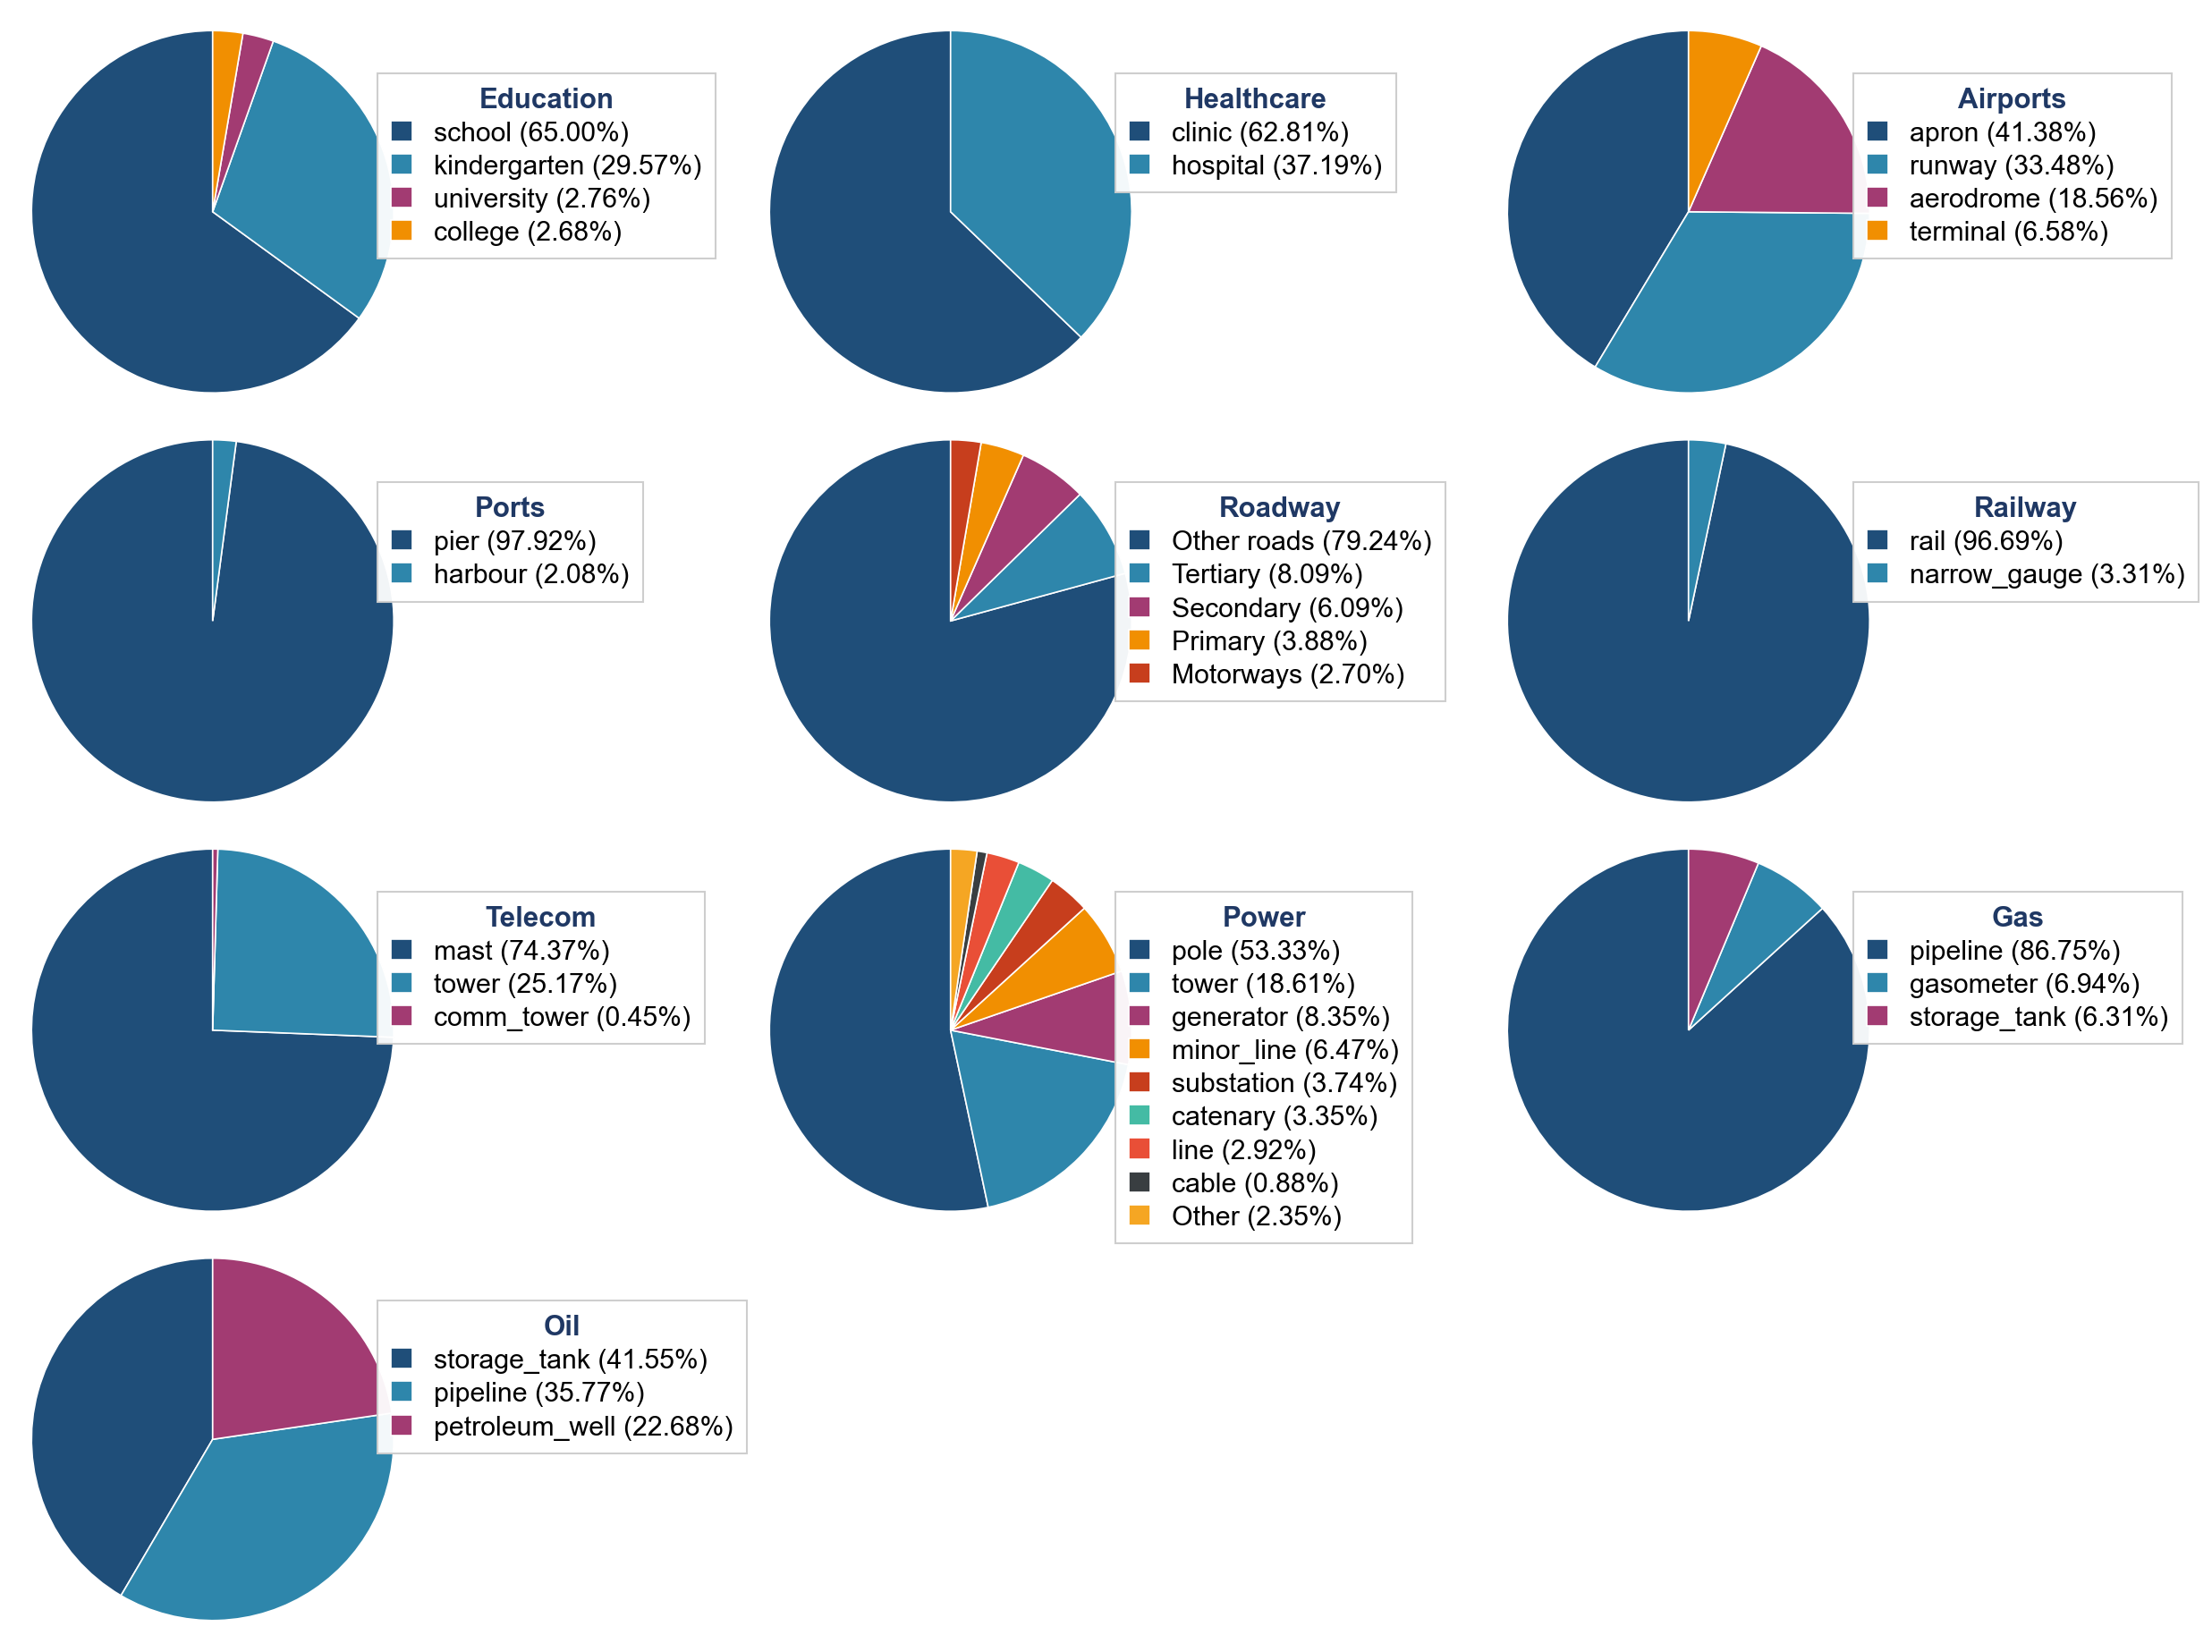

✔  Saved at 300 dpi → C:\Users\Paraskevi Tsoumani\miraca_exposure_database\Final\bouquet_of_pies.png


In [61]:
import matplotlib
matplotlib.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial"],
    "axes.titleweight": "bold",
})

# ── Short label mapping for long names ────────────────────────────────────────
LABEL_SHORT = {
    "Other roads":           "Other roads",
    "Tertiary roads":        "Tertiary",
    "Secondary roads":       "Secondary",
    "Primary Roads":         "Primary",
    "Motorways and Trunks":  "Motorways",
    "communications_tower":  "comm_tower",
    "catenary_mast":         "catenary",
    "minor_line":            "minor_line",
}

def get_europe_totals(network):
    df   = all_tables[network]
    cols = [c for c in df.columns if c != "TOTAL"]
    tot  = df[cols].sum().sort_values(ascending=False)
    return tot[tot > 0]

networks_avail = [n for n in NETWORKS if n in all_tables]
MAX_SLICES = 8

NCOLS = 3
NROWS = -(-len(networks_avail) // NCOLS)

# ── BIGGER figure so fonts are readable ───────────────────────────────────────
FIG_W = 16.5
FIG_H = NROWS + 9

fig = plt.figure(figsize=(FIG_W, FIG_H), facecolor="white")
# fig.text(0.5, 0.99,
#          "Critical Infrastructure Exposure Database\nEurope-wide feature composition by network",
#          ha="center", va="top", fontsize=14, fontweight="bold", color="#1F3864")

cell_w  = 1.0 / NCOLS
cell_h  = (FIG_H - 0.8) / FIG_H / NROWS
pie_w   = 0.18
pie_h   = pie_w * (FIG_W / FIG_H)
leg_w   = cell_w - pie_w - 0.01
pad_x   = 0.015
pad_y   = 0.03

for idx, network in enumerate(networks_avail):
    row_i = idx // NCOLS
    col_i = idx  %  NCOLS

    totals = get_europe_totals(network)
    if len(totals) > MAX_SLICES:
        totals = pd.concat([
            totals.iloc[:MAX_SLICES],
            pd.Series({"Other": totals.iloc[MAX_SLICES:].sum()})
        ])

    # Shorten labels
    short_index = [LABEL_SHORT.get(lbl, lbl) for lbl in totals.index]
    totals.index = short_index

    colors = PALETTE[:len(totals)]
    grand  = totals.sum()

    #title_frac = 0.8 / FIG_H
    row_bottom = 1.0 - title_frac - (row_i + 1) * cell_h
    pie_left   = col_i * cell_w + pad_x
    pie_bottom = row_bottom + (cell_h - pie_h) / 2

    ax_pie = fig.add_axes([pie_left, pie_bottom, pie_w, pie_h])
    wedges, _ = ax_pie.pie(
        totals.values, colors=colors, radius=1.0, startangle=90,
        autopct=None,
        wedgeprops={"edgecolor": "white", "linewidth": 0.8},
    )
    ax_pie.axis("equal")

    leg_left   = pie_left + pie_w + 0.004
    leg_bottom = row_bottom + pad_y
    leg_height = cell_h - 2 * pad_y

    ax_leg = fig.add_axes([leg_left, leg_bottom, leg_w - 0.015, leg_height])
    ax_leg.axis("off")

    legend_labels = [
        f"{lbl} ({v/grand*100:.2f}%)"
        for lbl, v in zip(totals.index, totals.values)
    ]
    leg = ax_leg.legend(
        wedges, legend_labels,
        loc="upper left", bbox_to_anchor=(-0.2, 1.0),
        fontsize=14.5,
        frameon=True, framealpha=0.95,
        edgecolor="#cccccc", fancybox=False,
        handlelength=0.8, handleheight=0.8,
        borderpad=0.5, labelspacing=0.30,
        title=network,
        title_fontsize=15,
    )
    leg.get_title().set_fontweight("bold")
    leg.get_title().set_color("#1F3864")
    leg.get_title().set_ha("left")

out_pie = OUTPUT_DIR / "bouquet_of_pies.png"
fig.savefig(out_pie, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"✔  Saved at 300 dpi → {out_pie}")

## Section 5 – Stacked bar charts: feature counts by country
One chart per network. Bars are stacked by object type. Saved as `bar_{network}.png`.

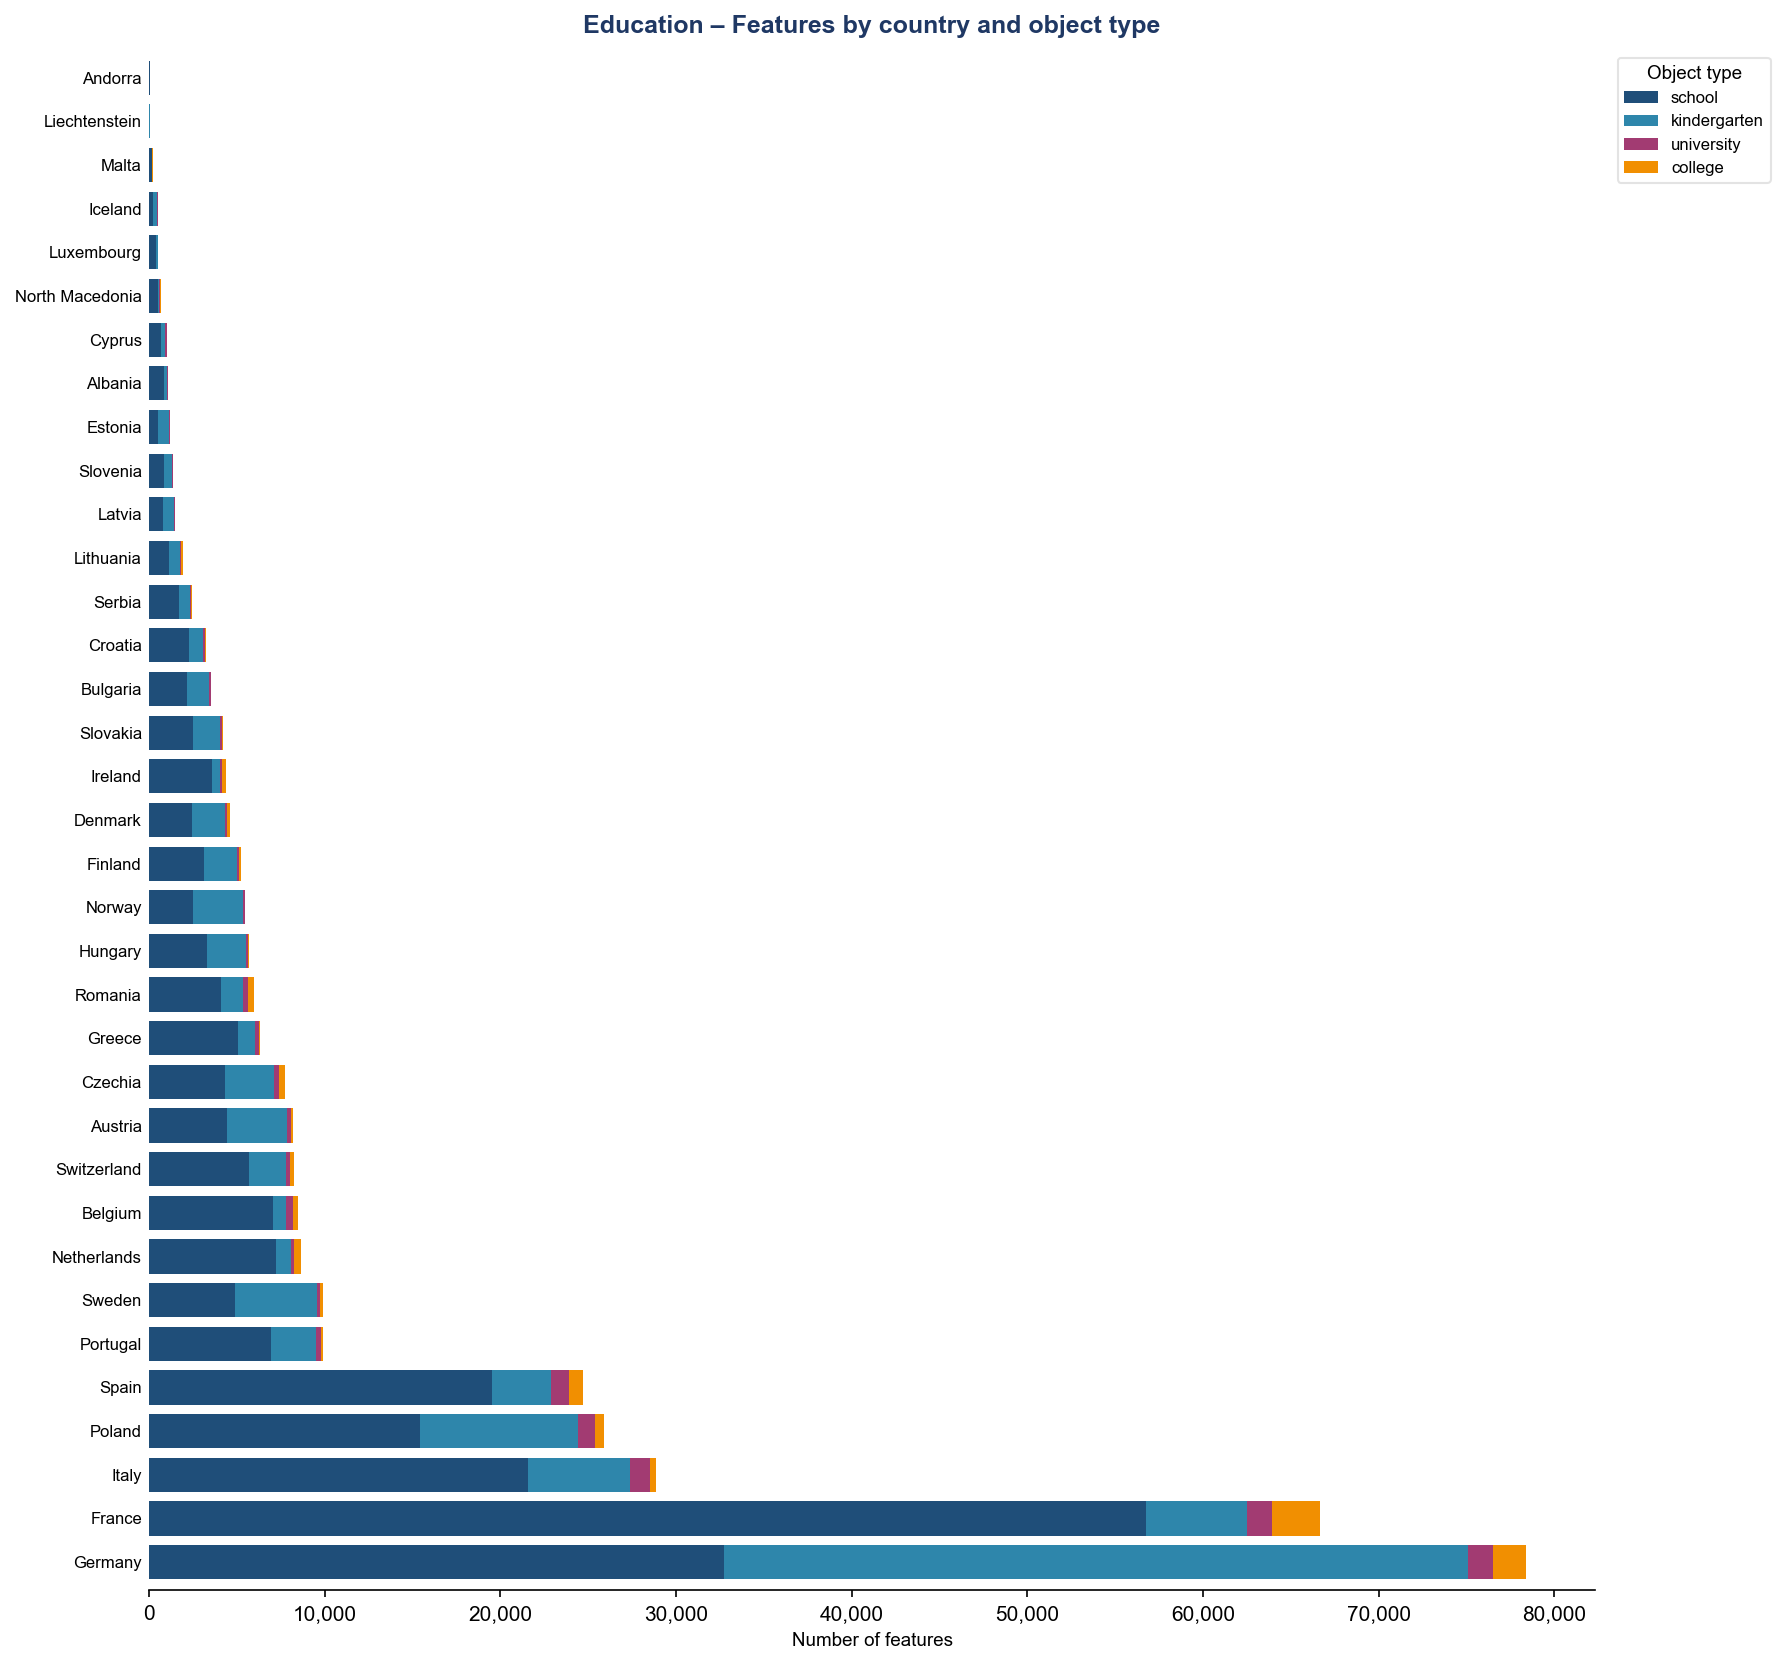

  Saved: bar_Education.png


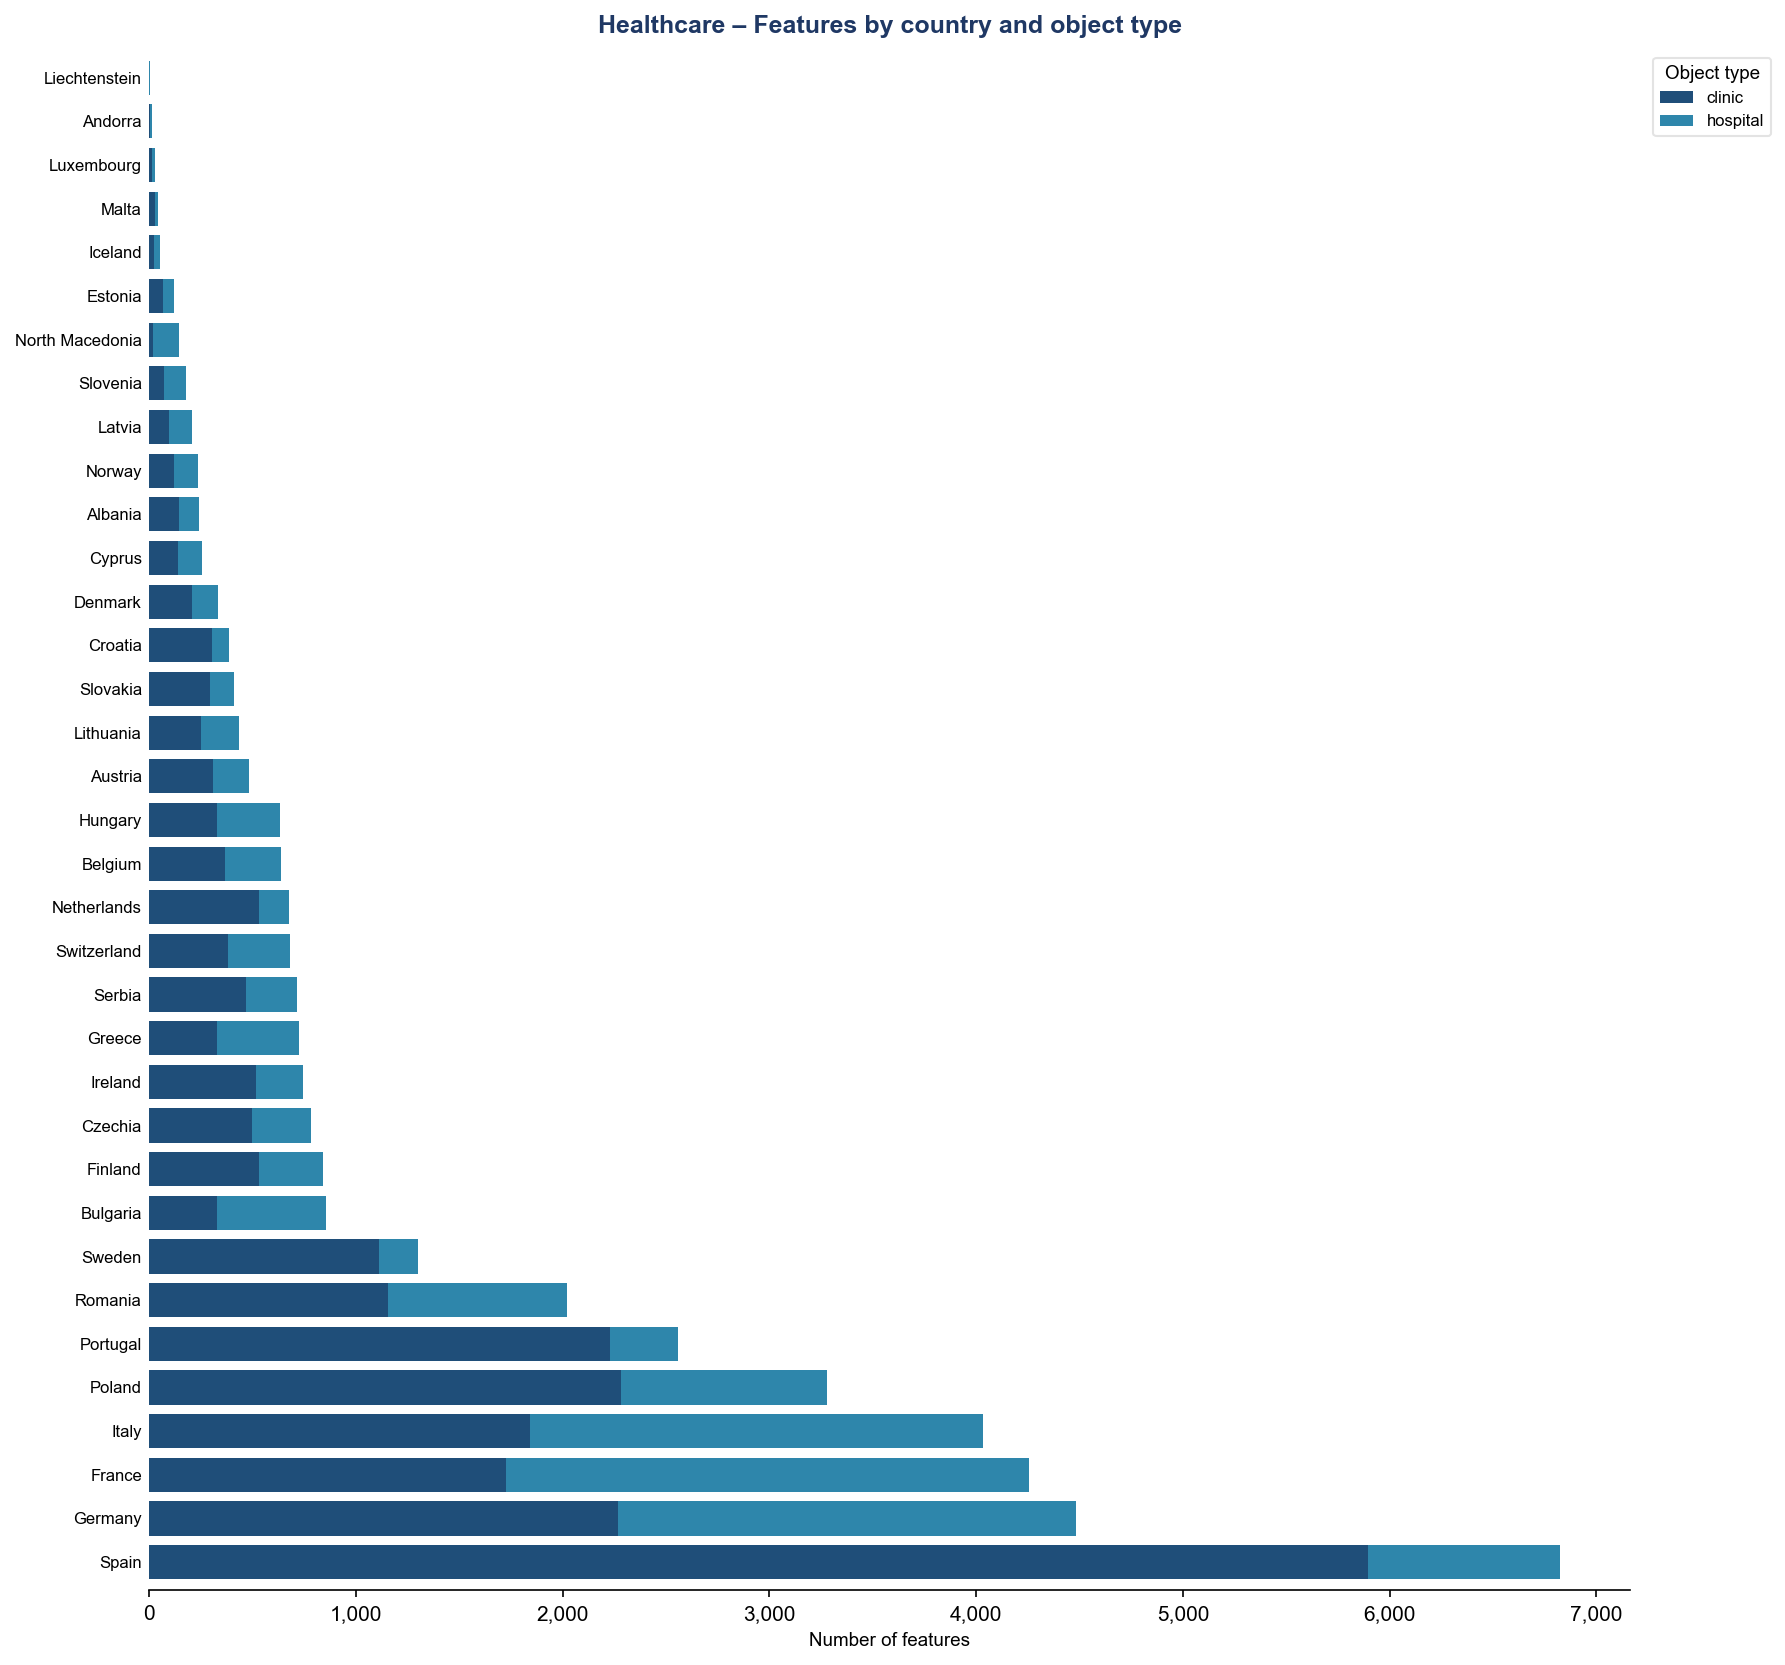

  Saved: bar_Healthcare.png


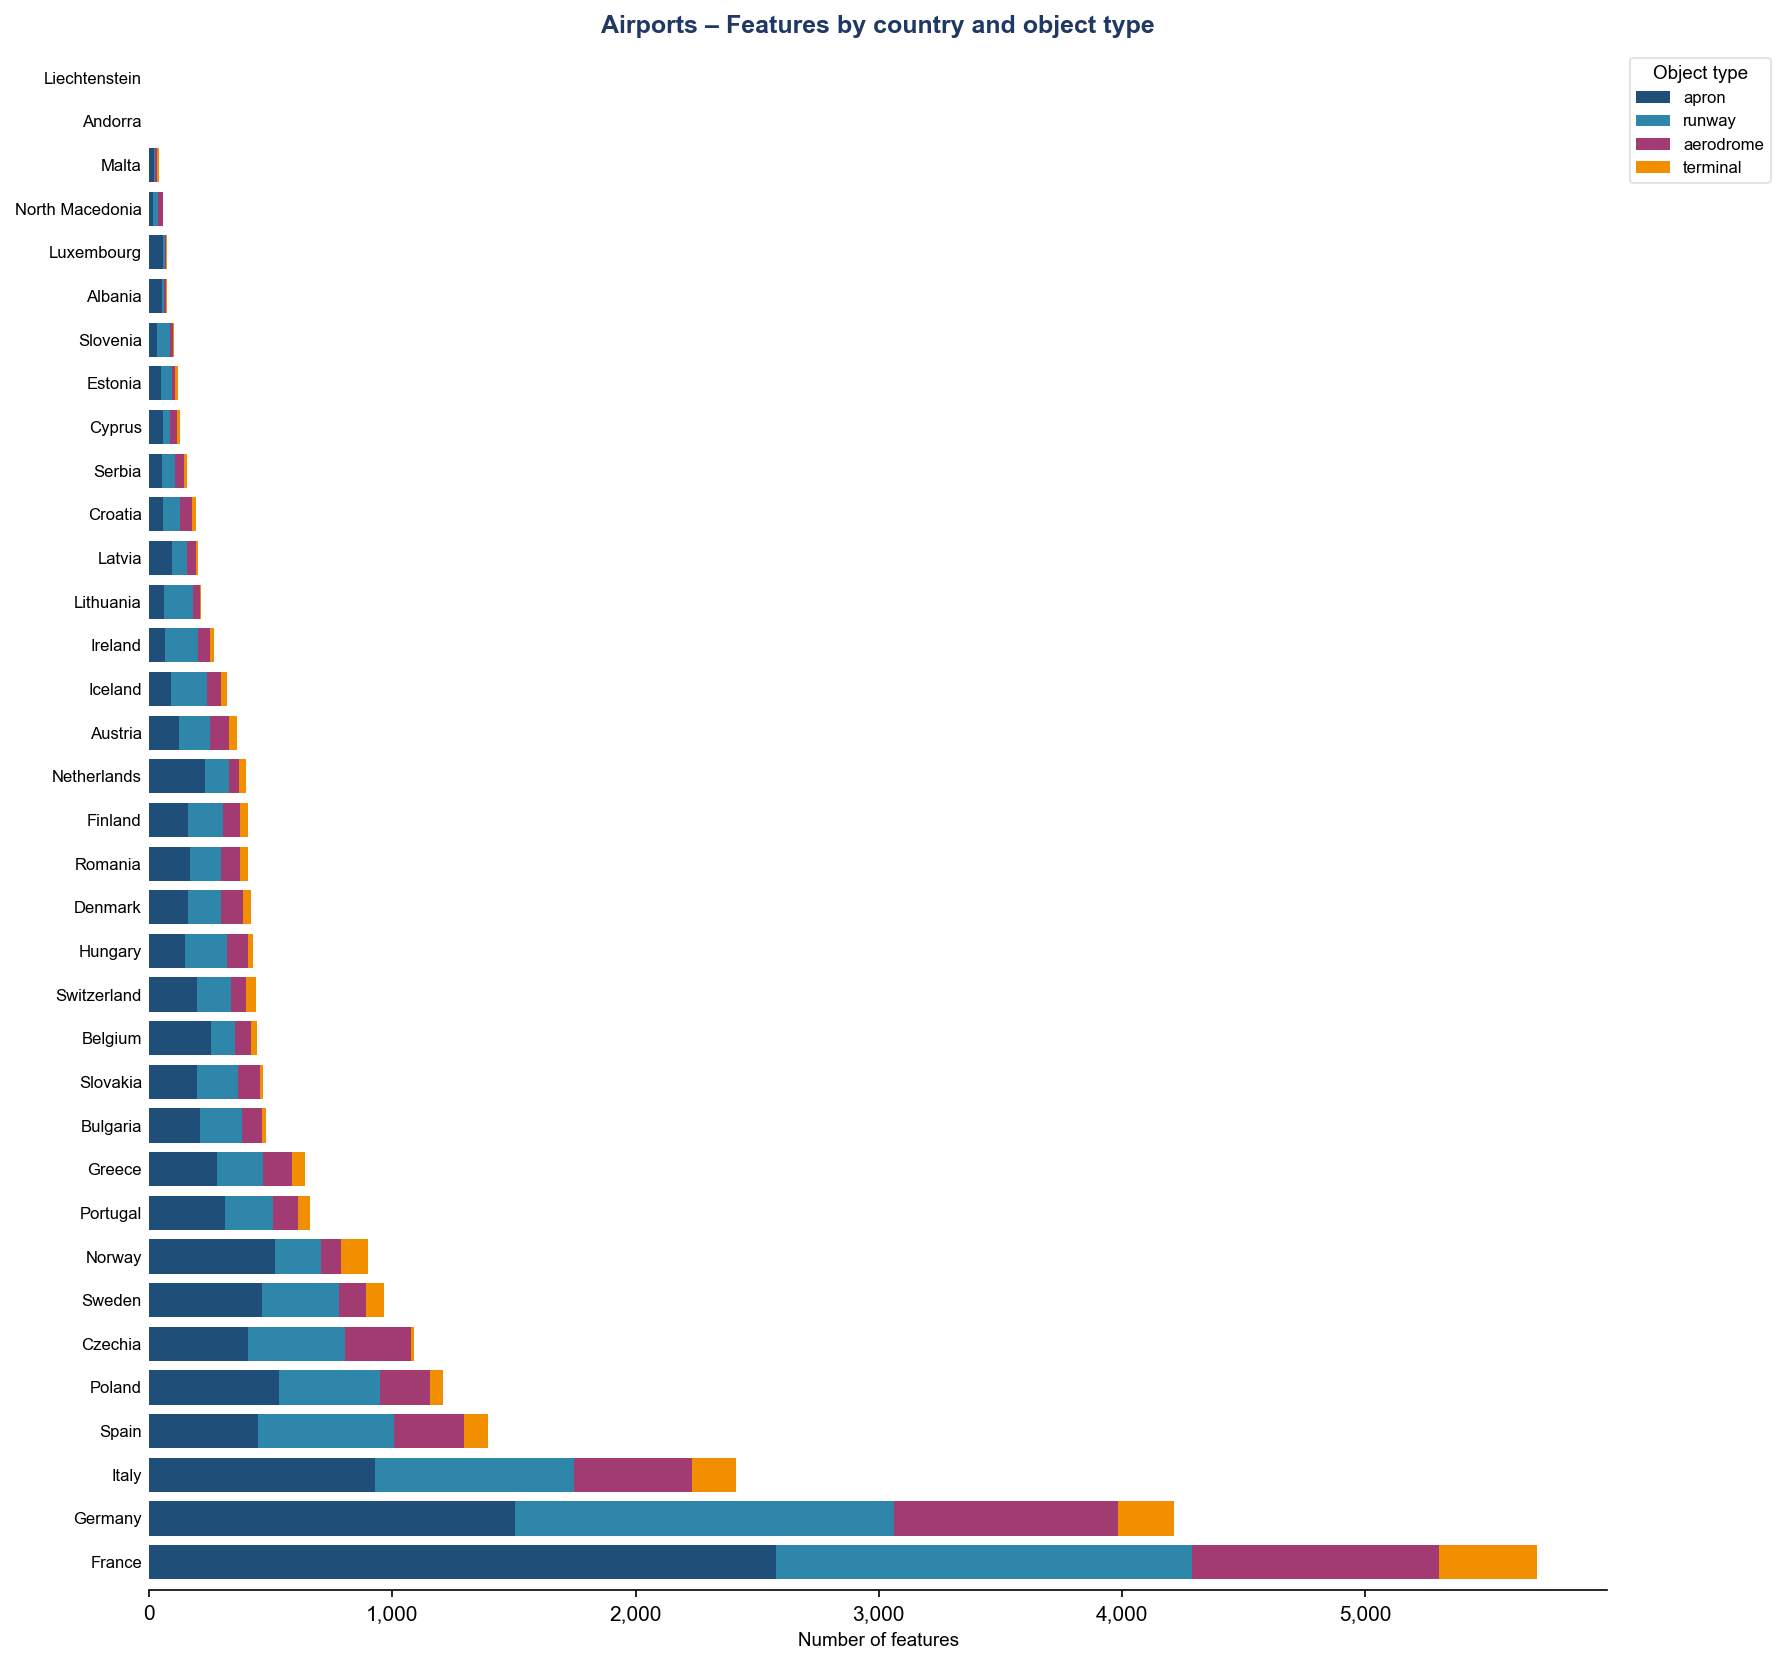

  Saved: bar_Airports.png


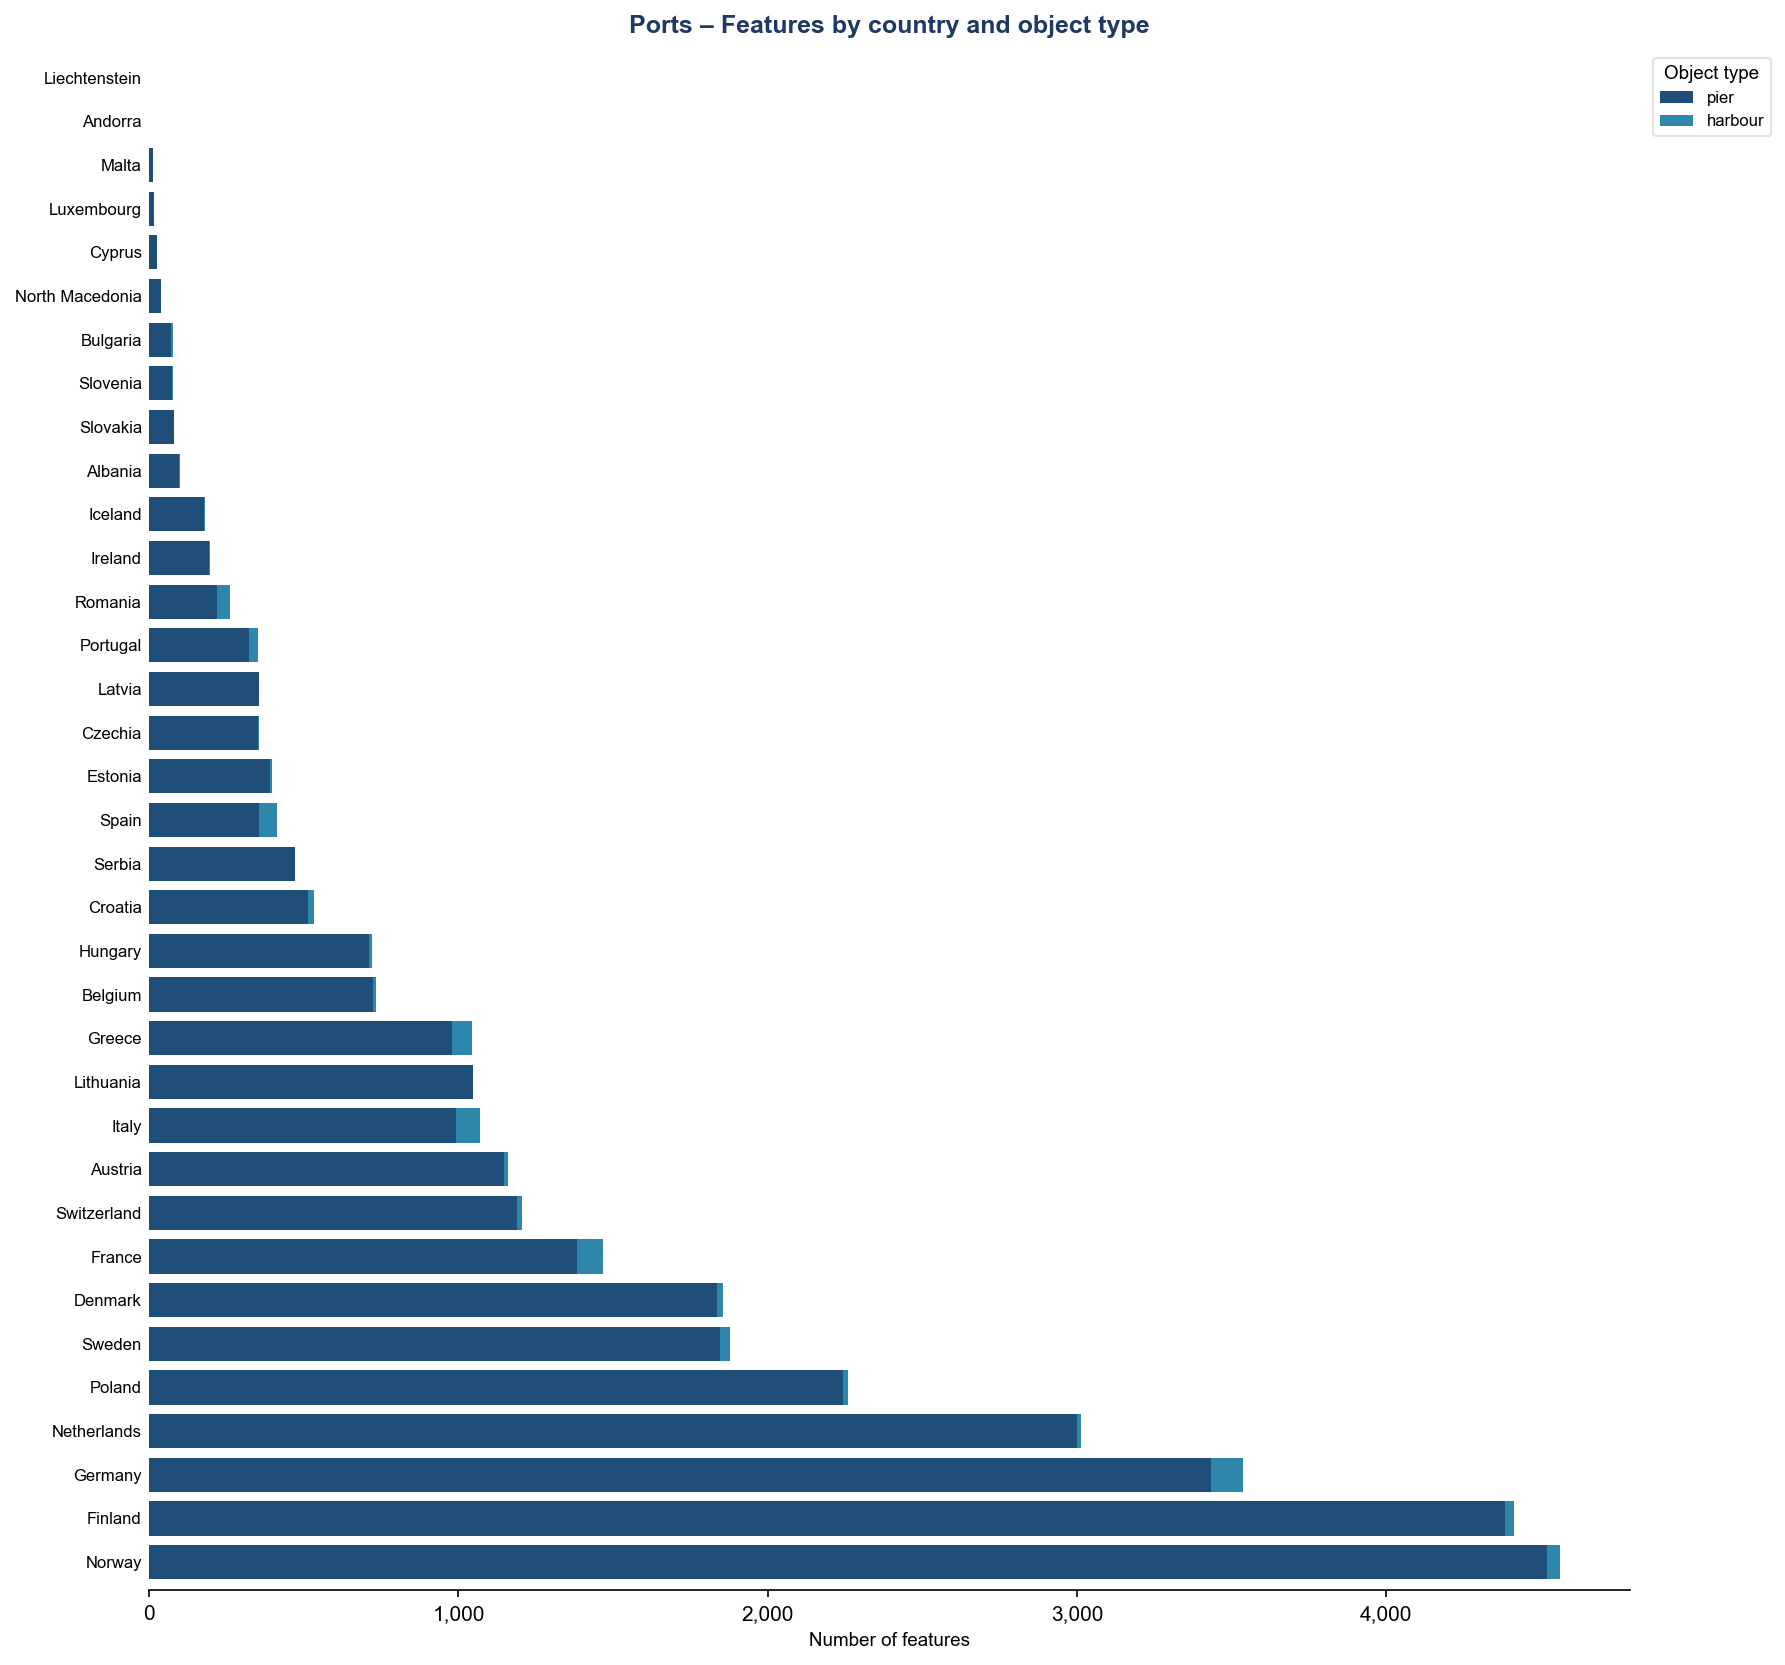

  Saved: bar_Ports.png


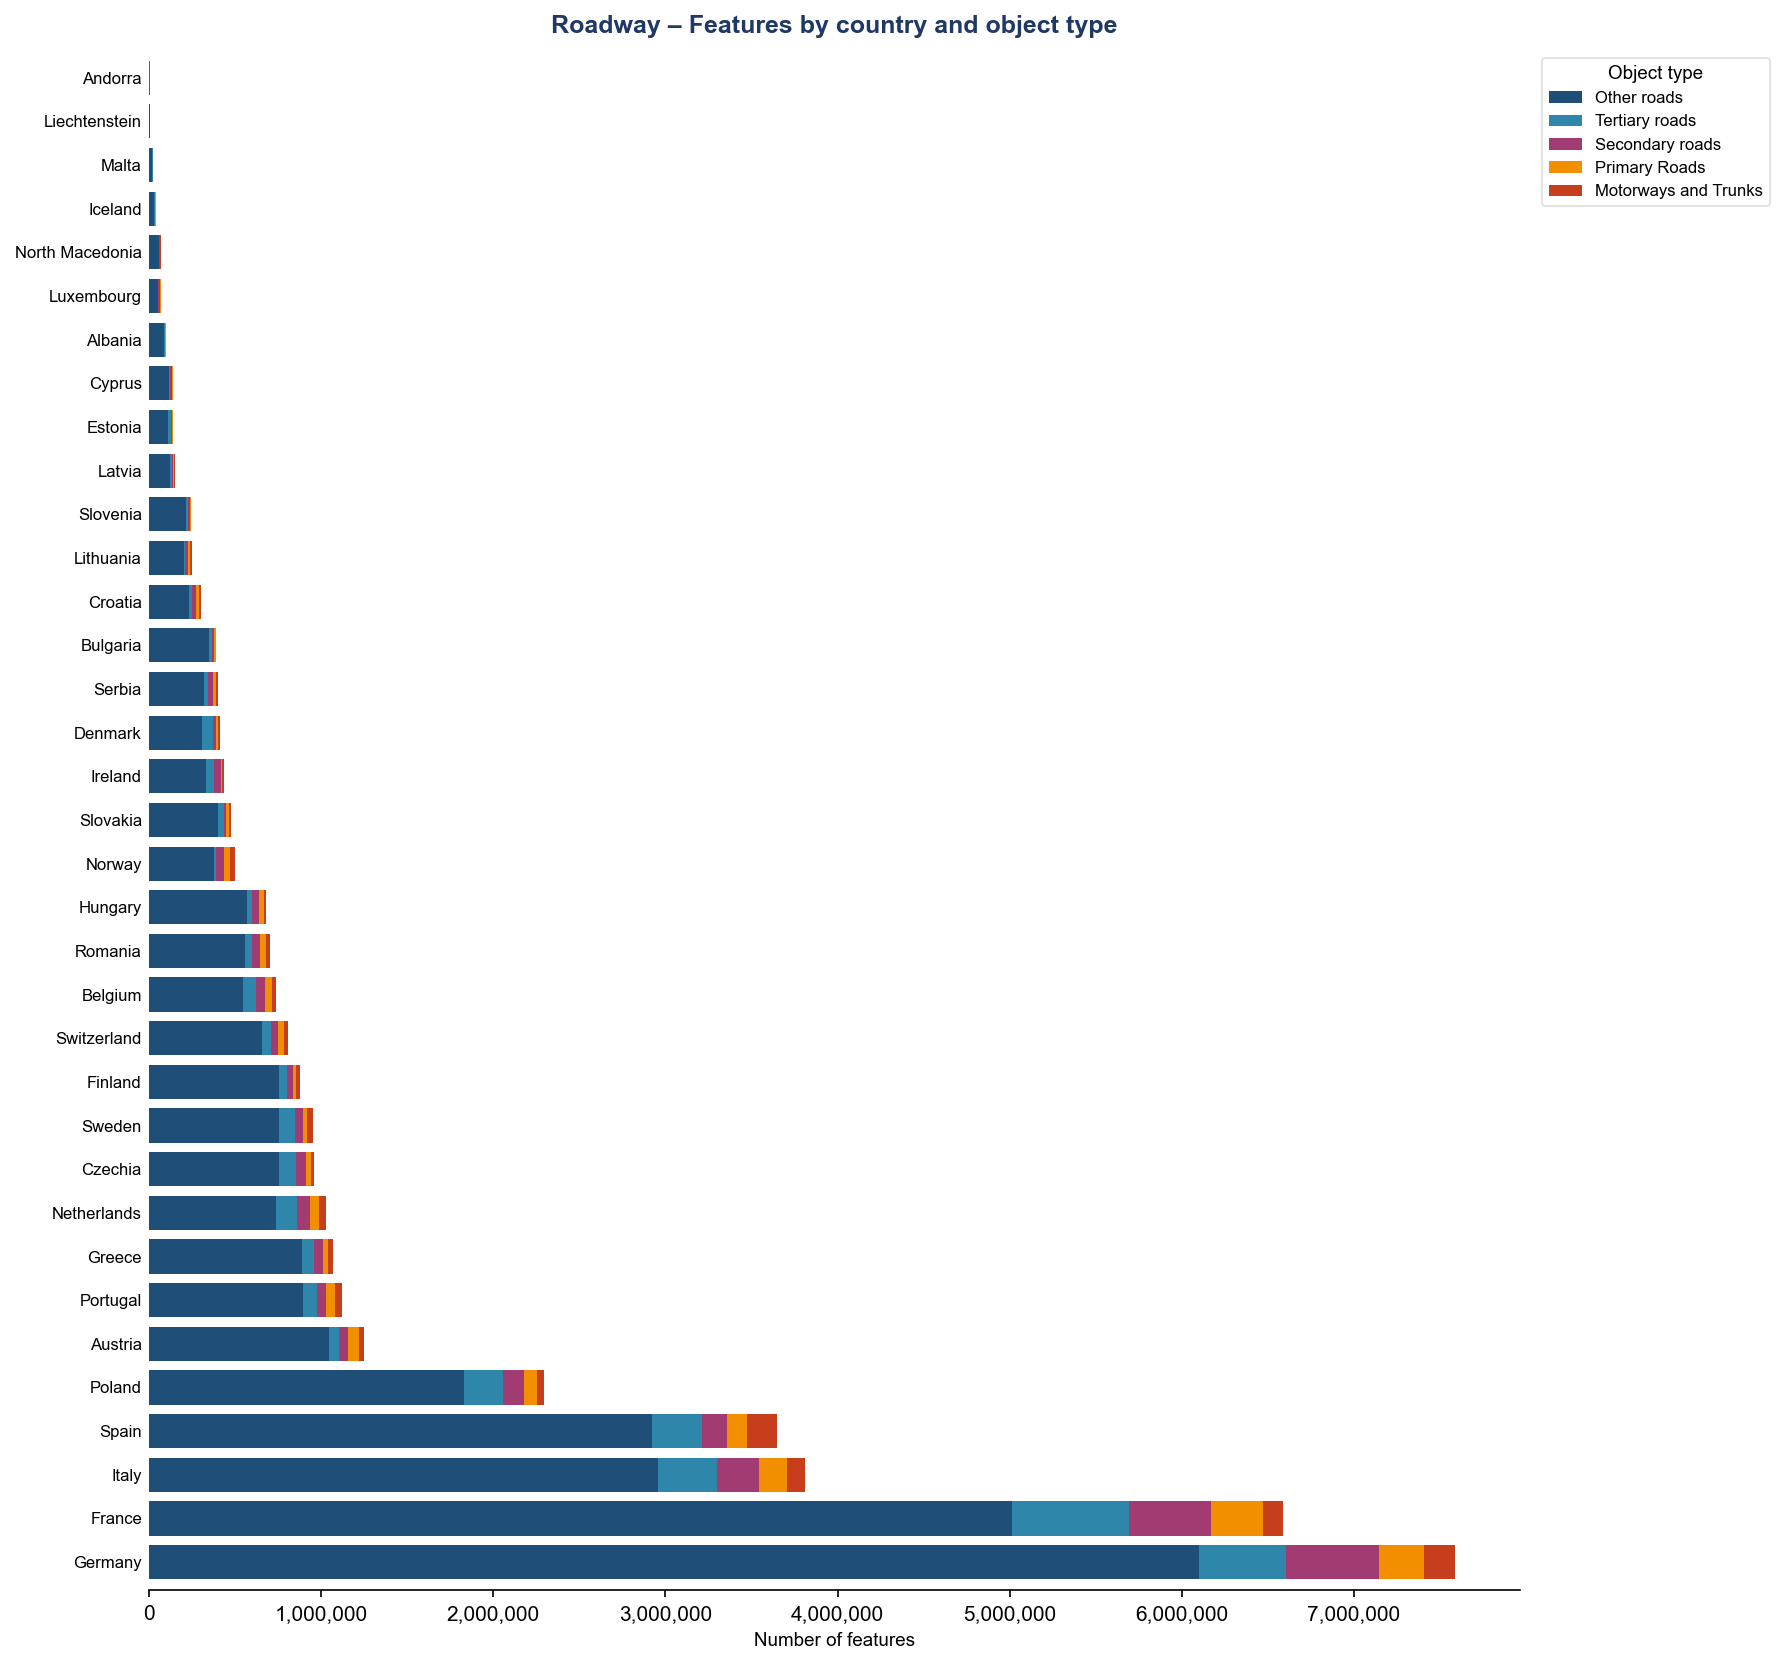

  Saved: bar_Roadway.png


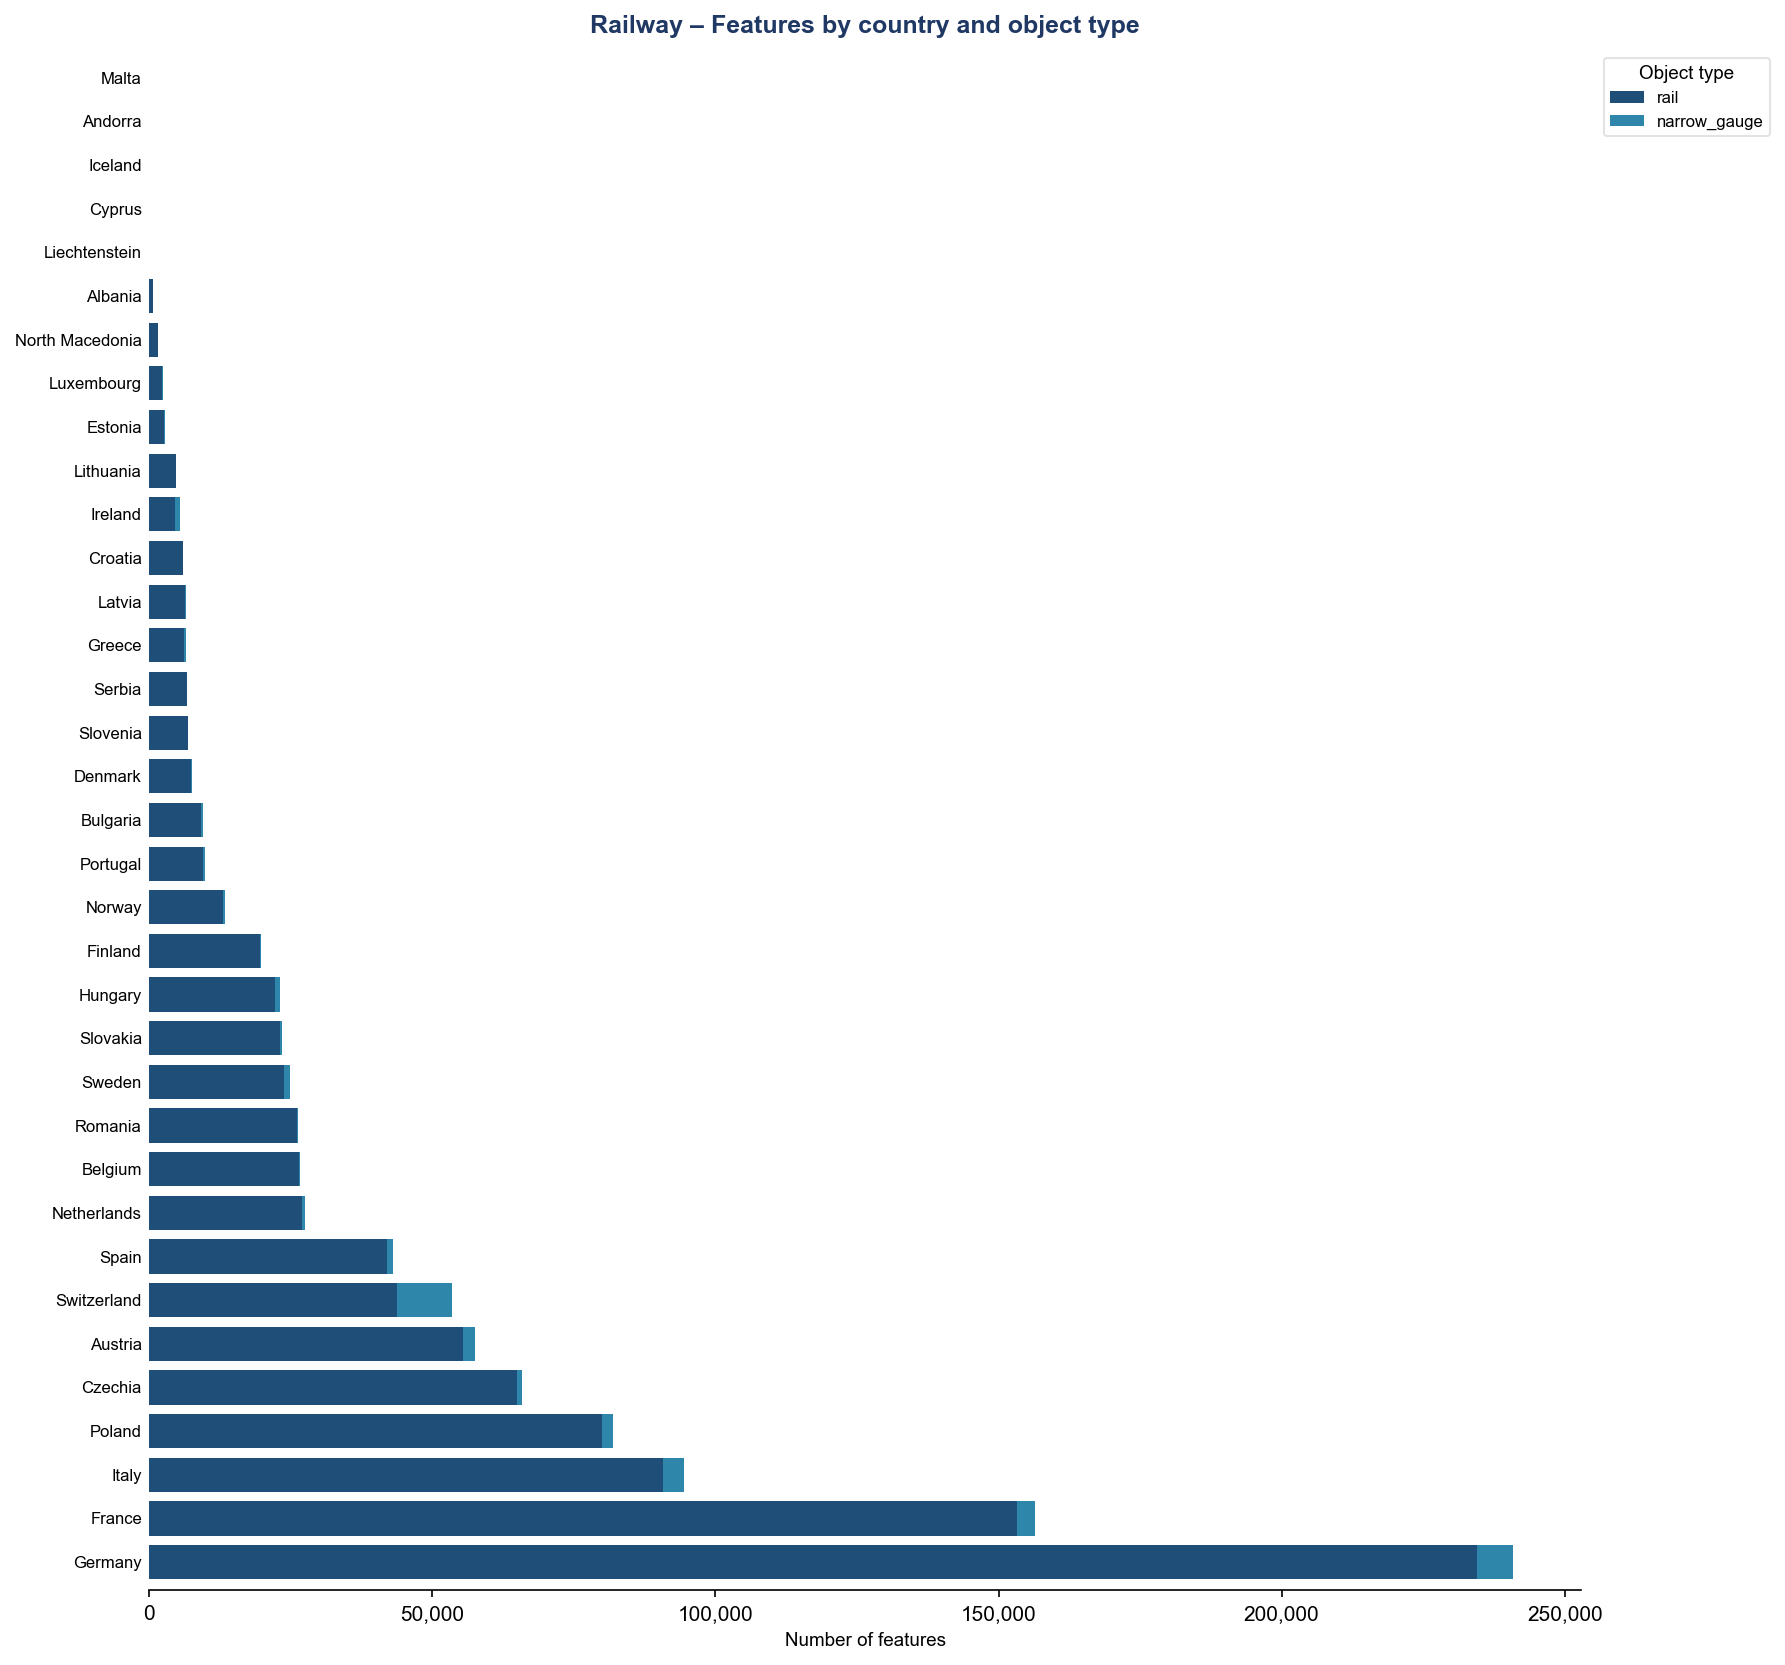

  Saved: bar_Railway.png


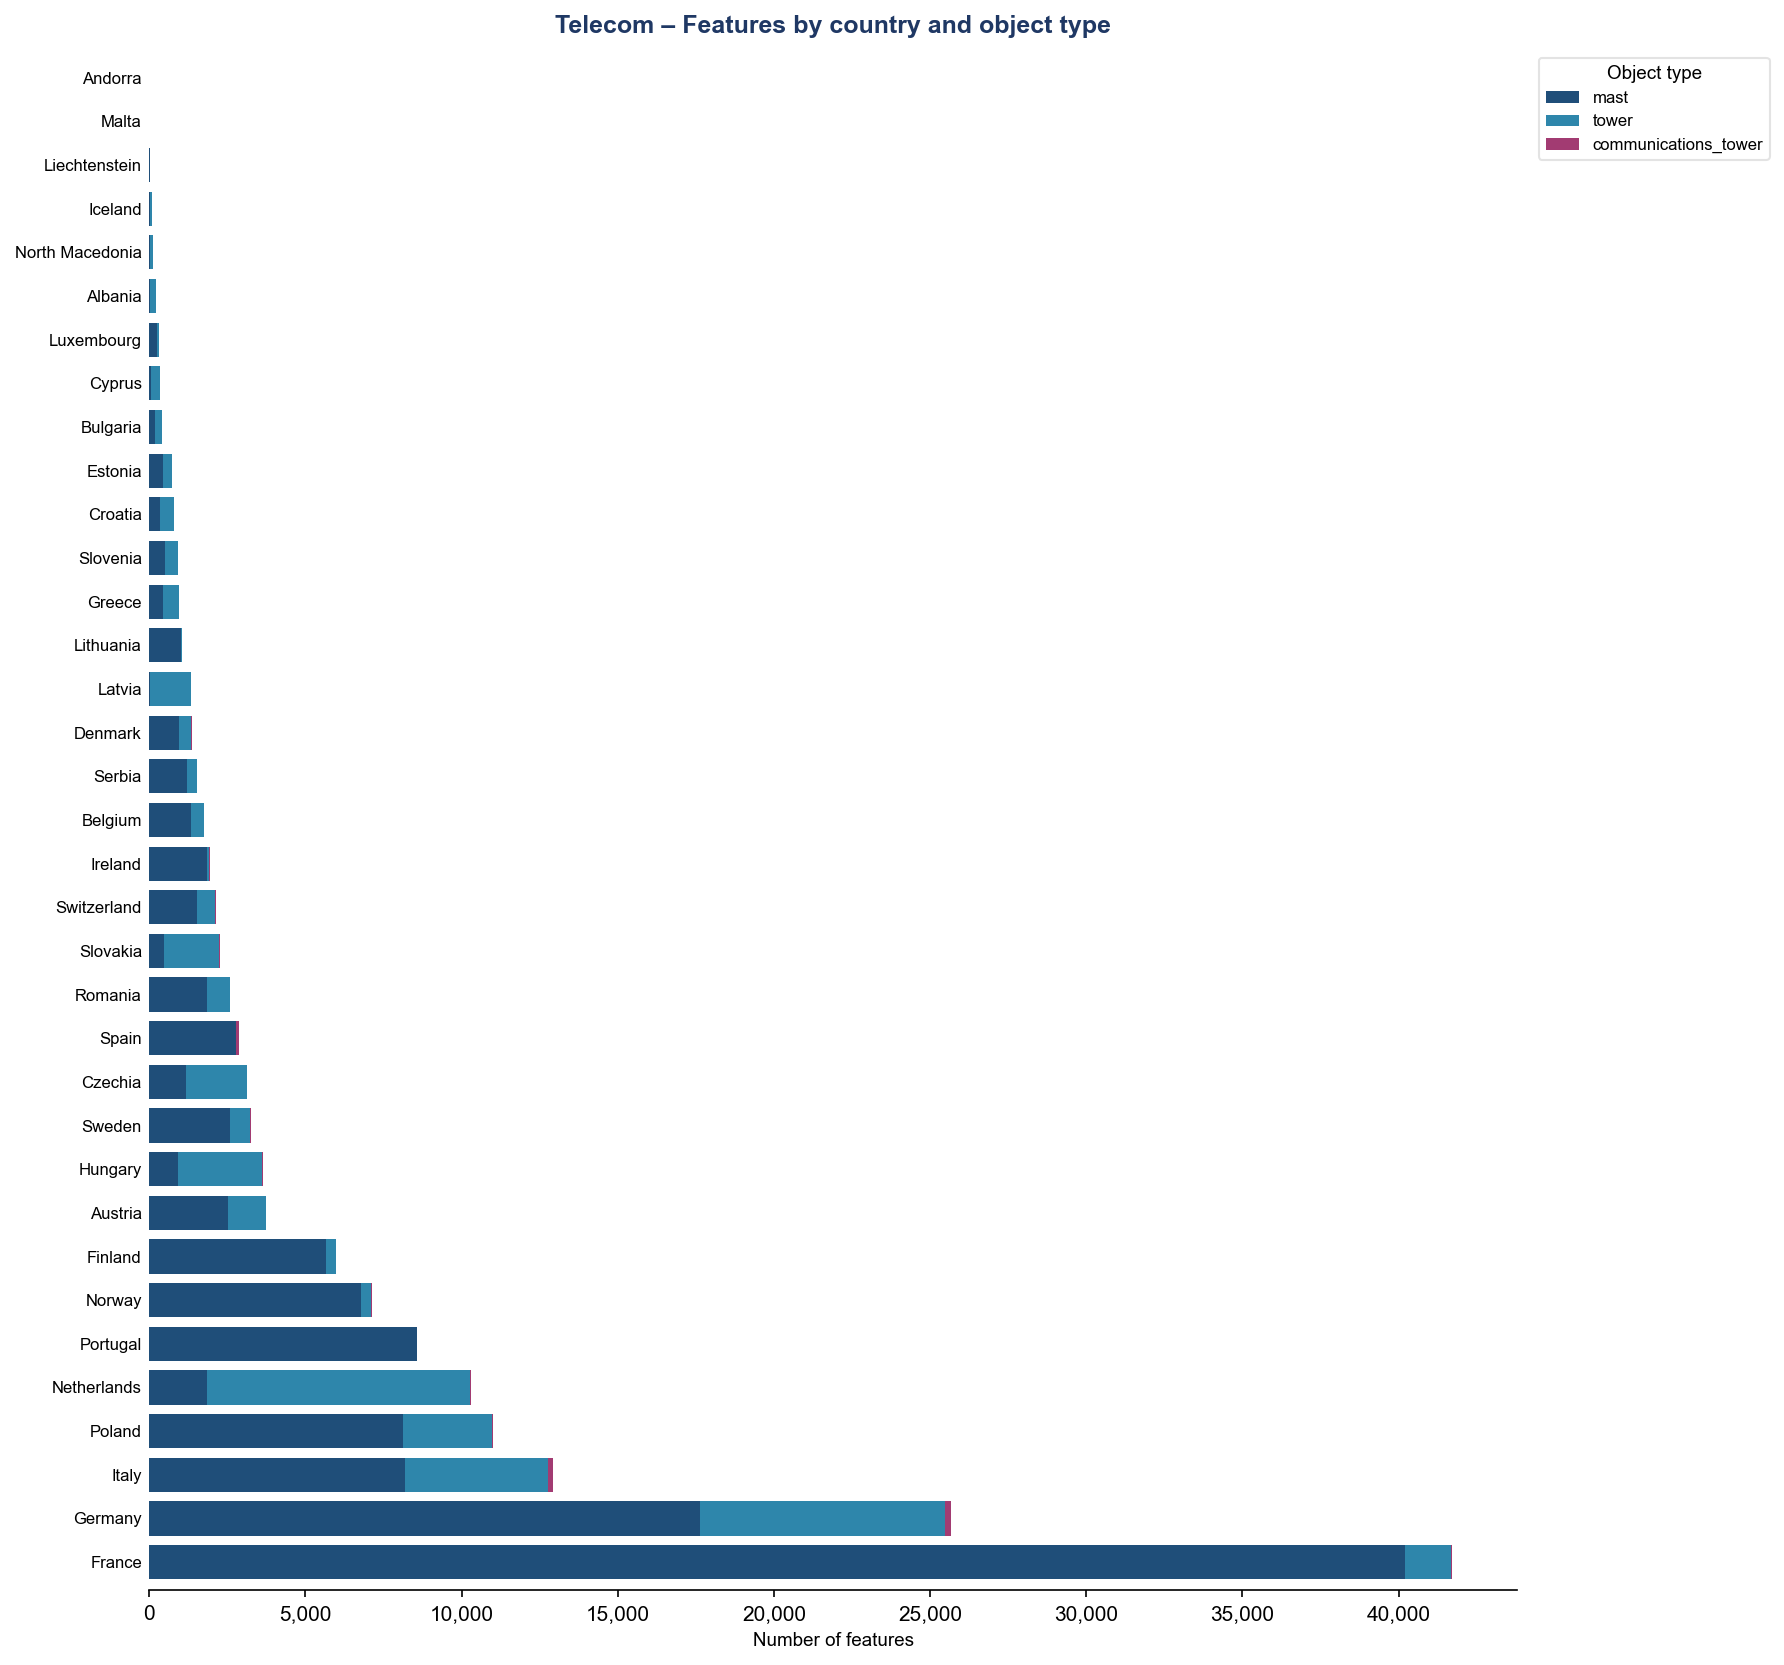

  Saved: bar_Telecom.png


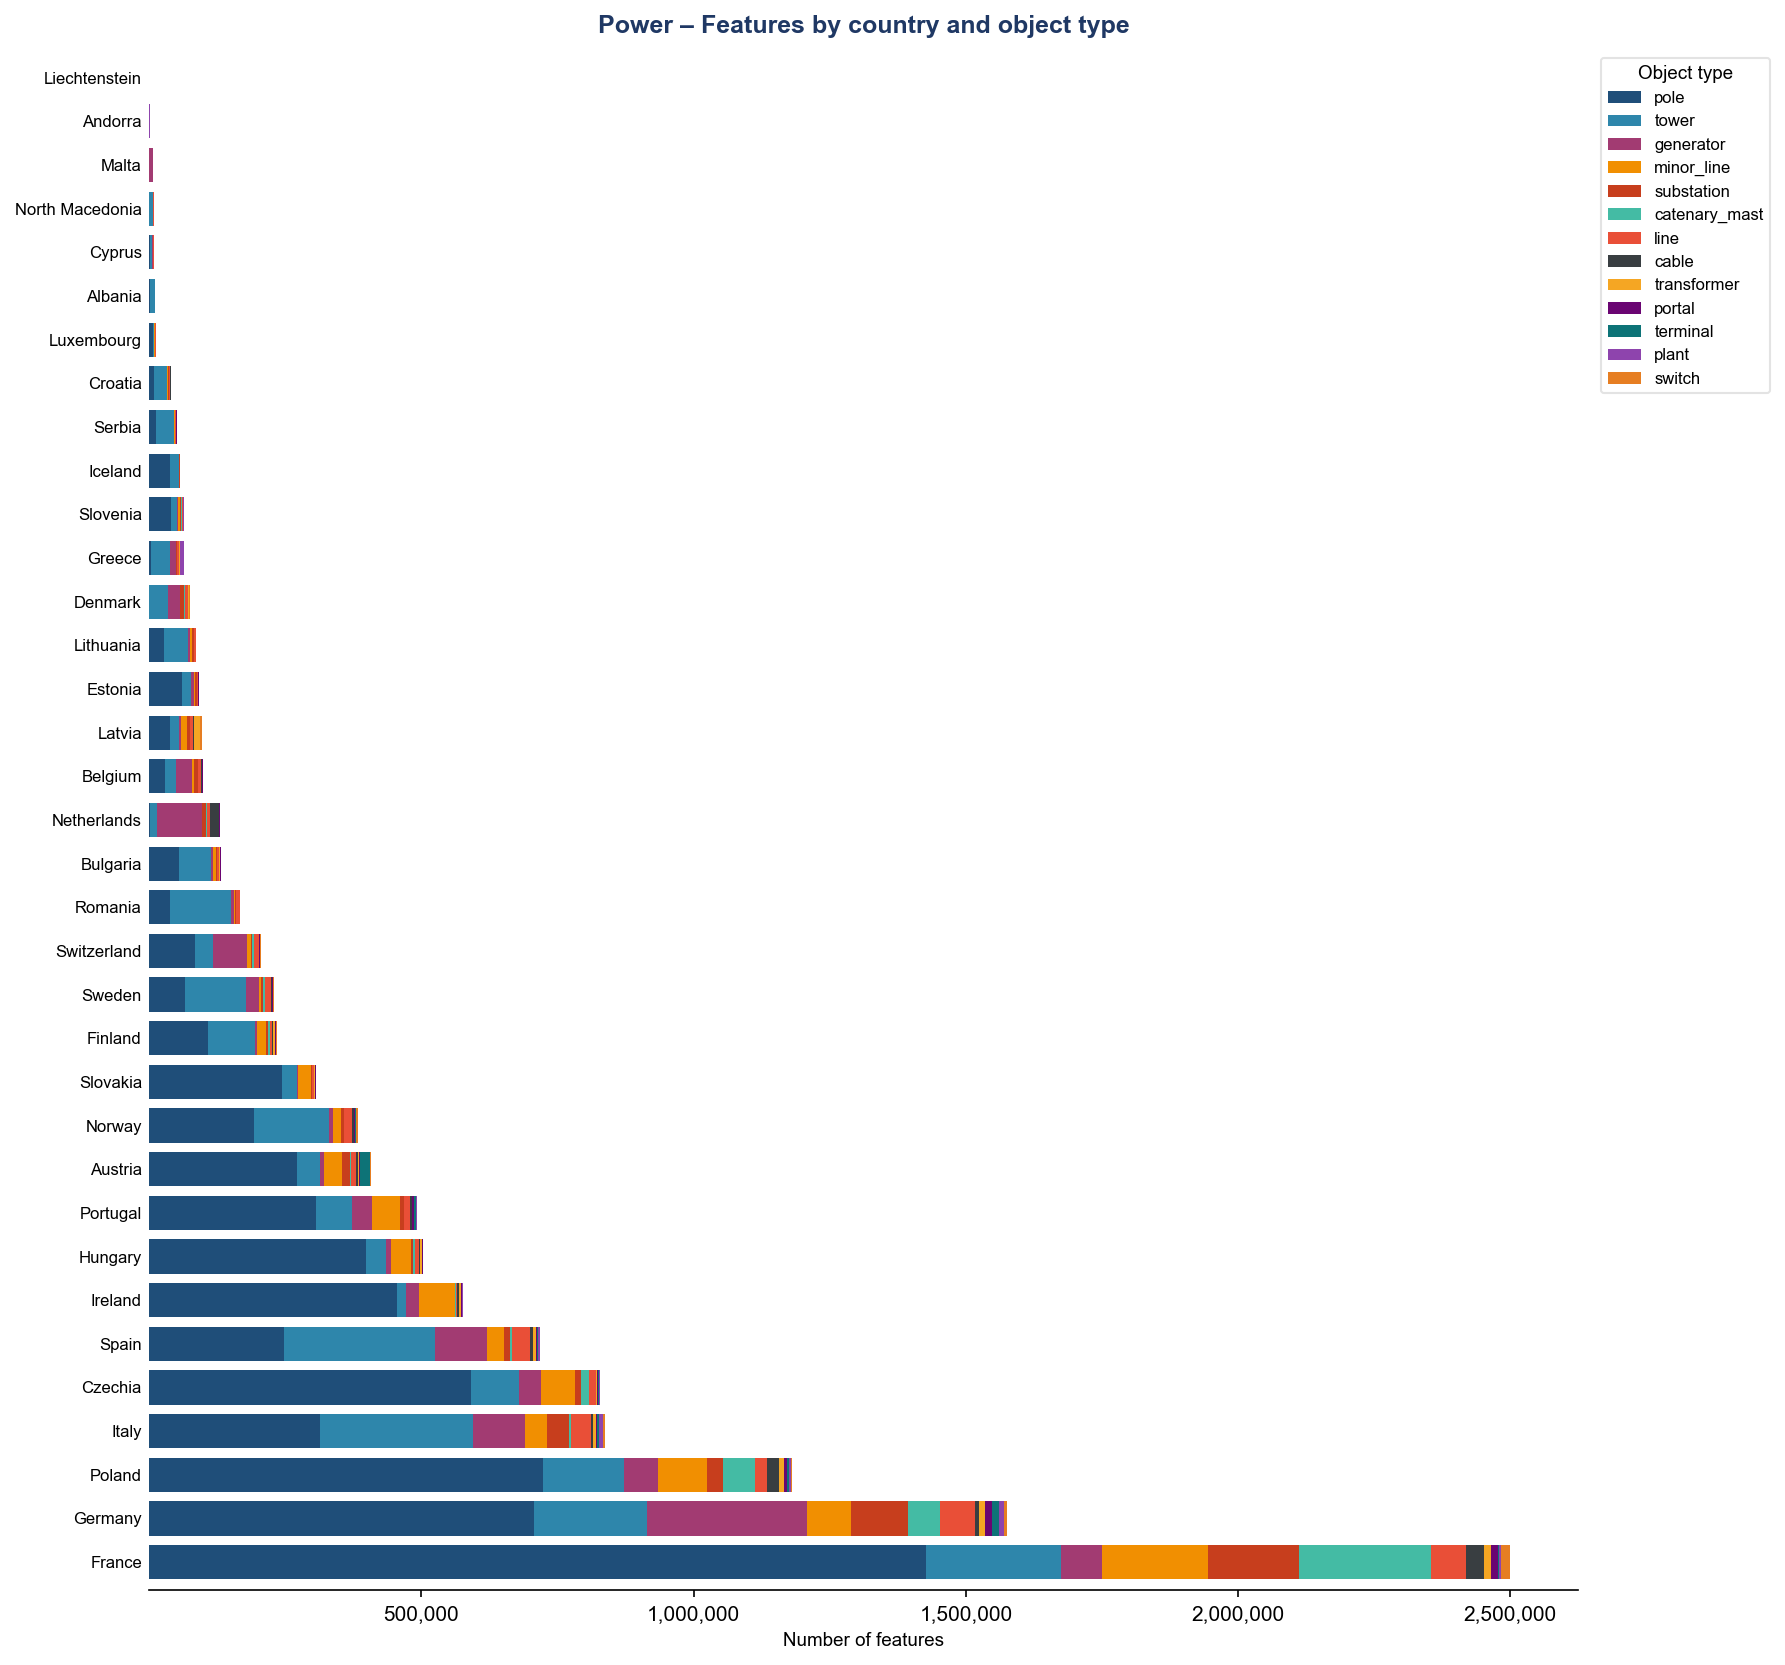

  Saved: bar_Power.png


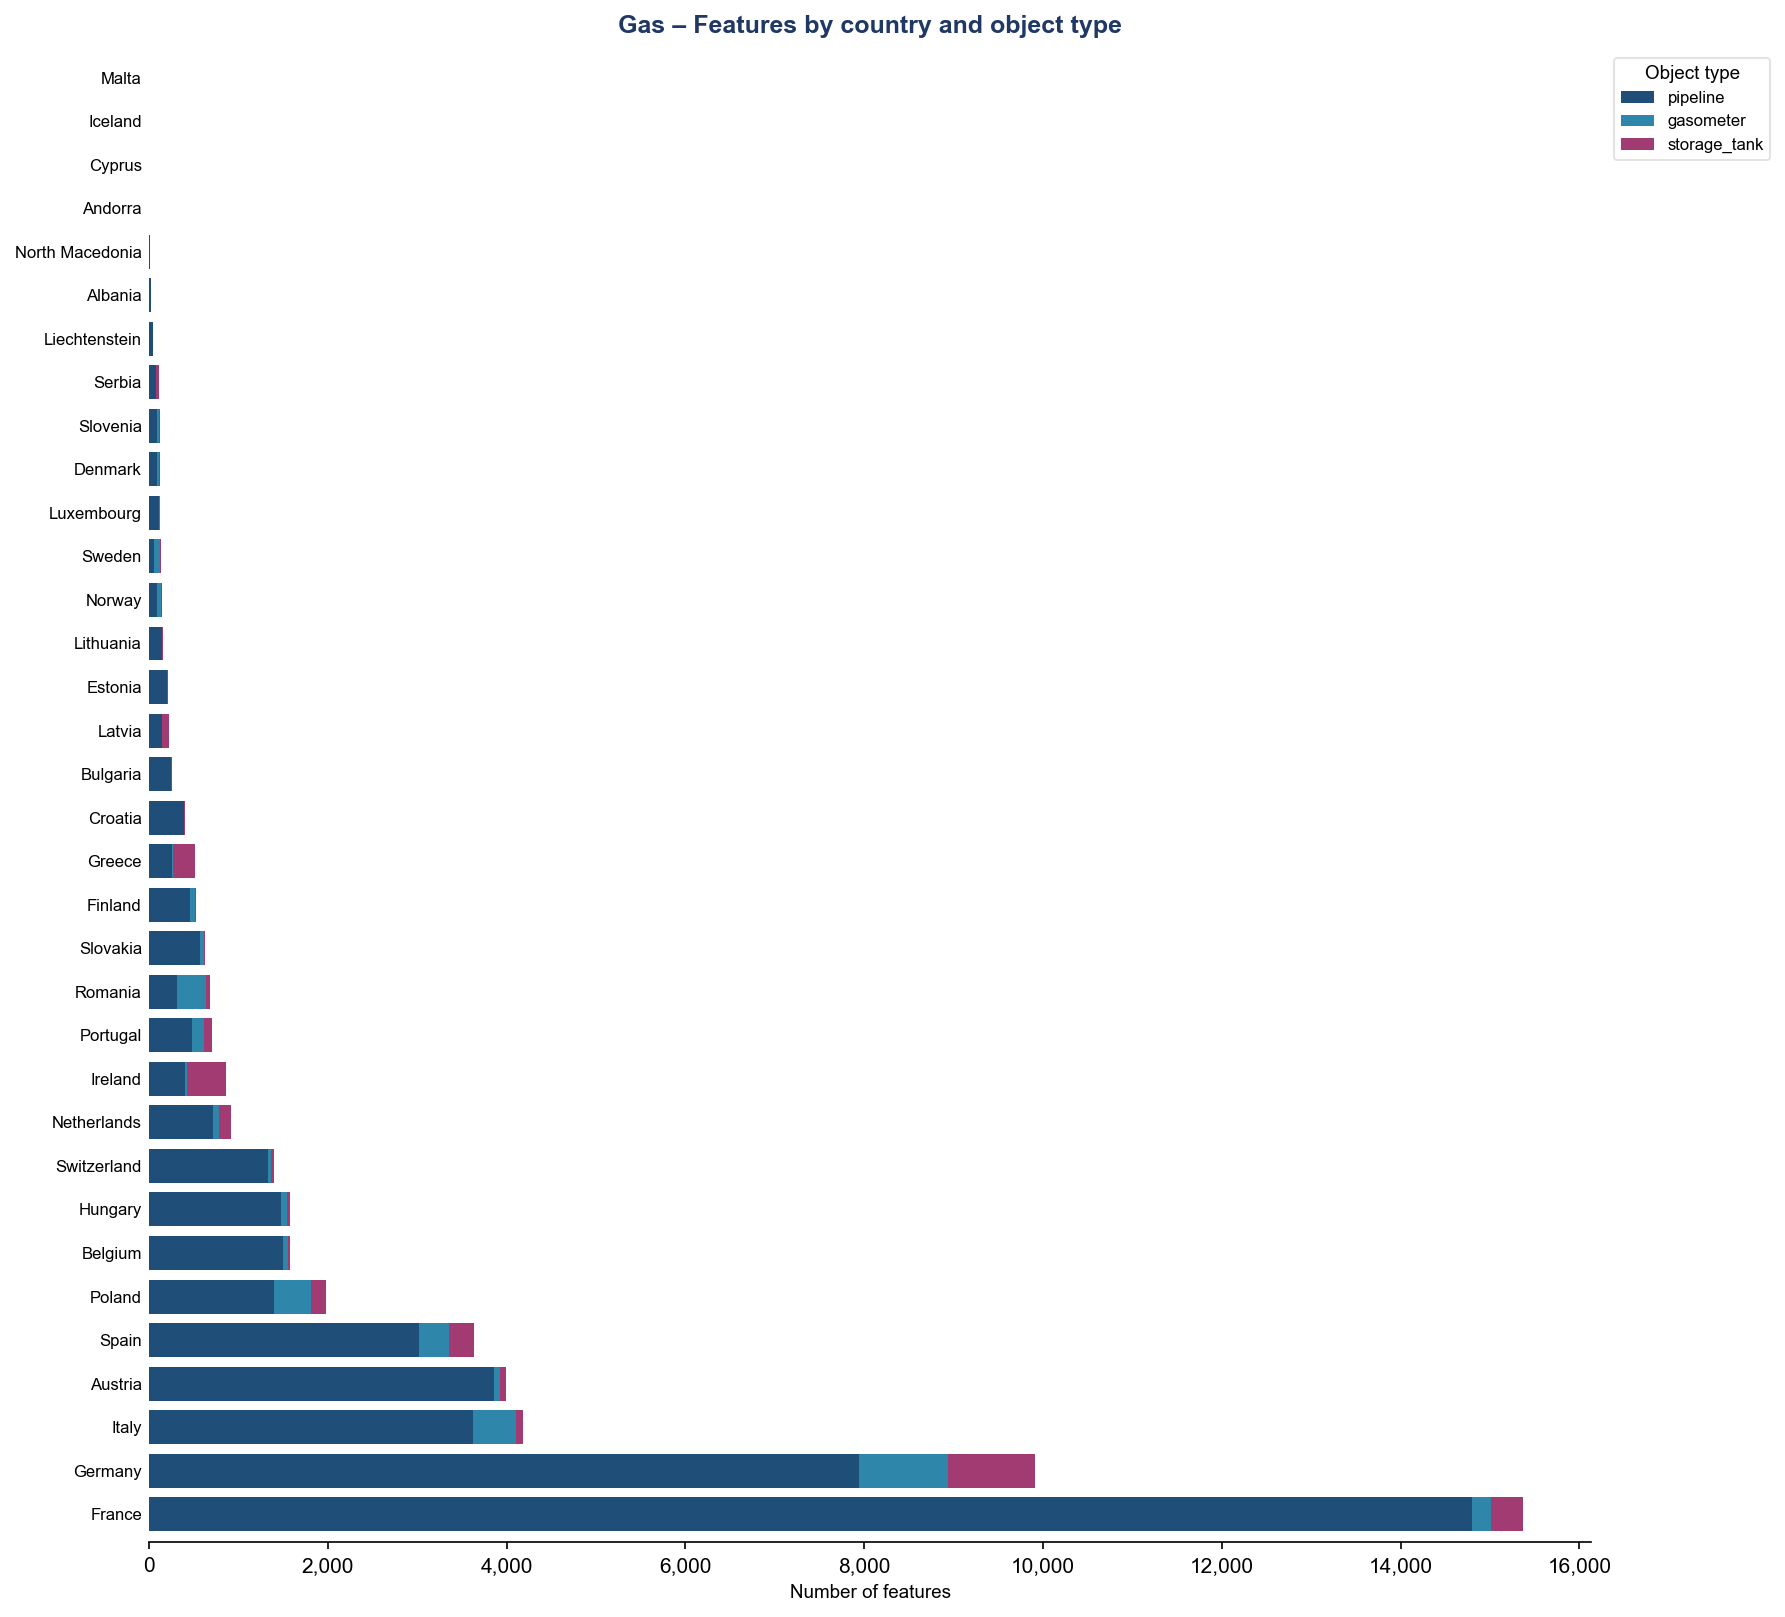

  Saved: bar_Gas.png


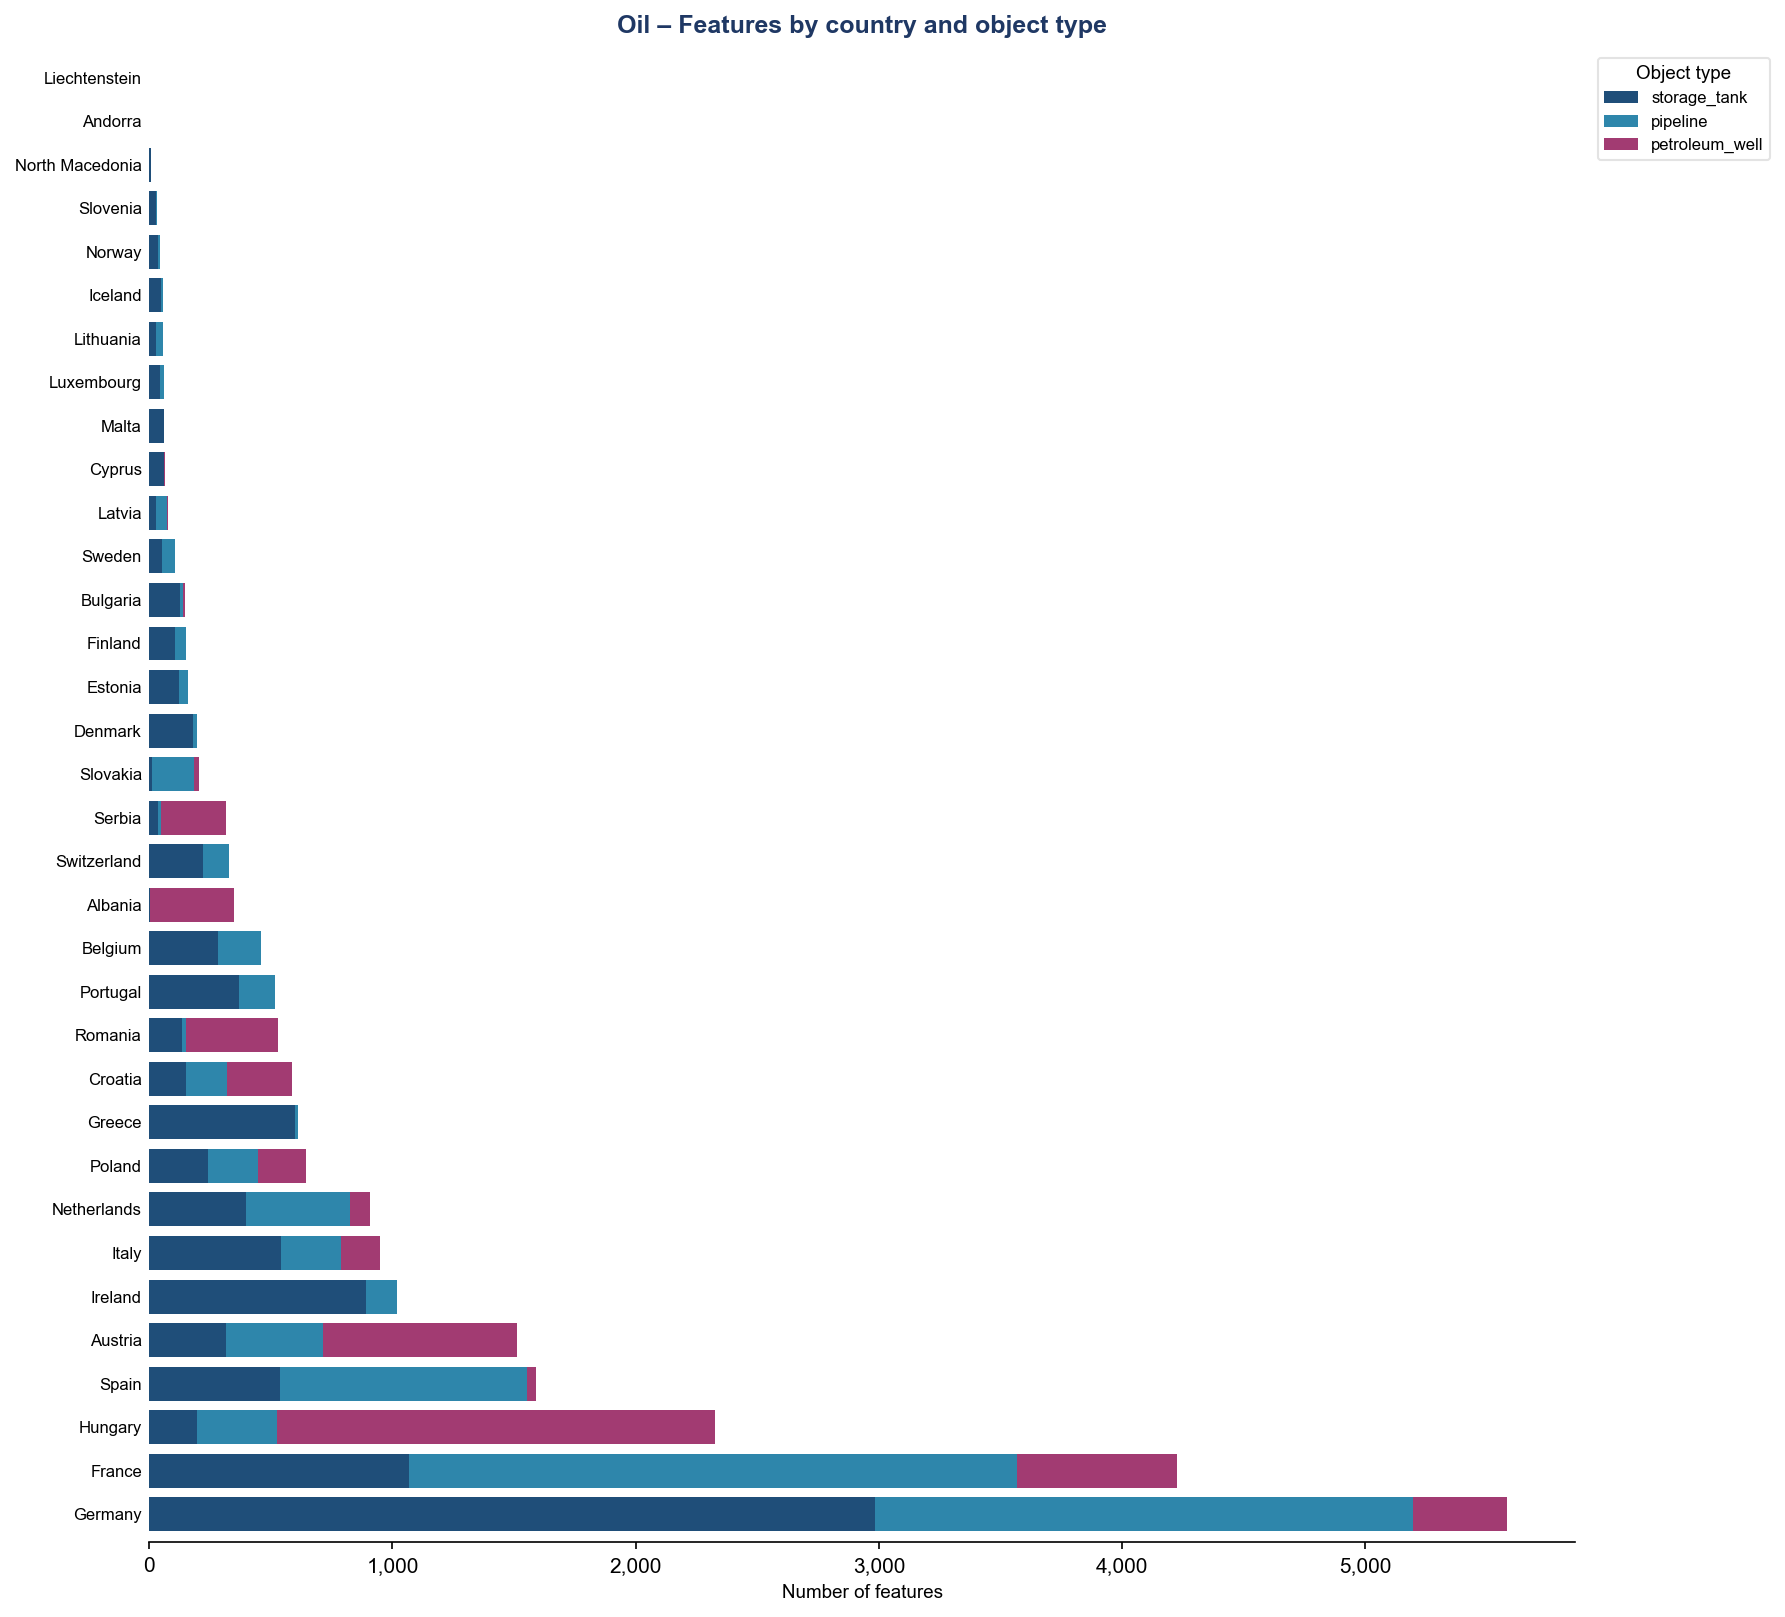

  Saved: bar_Oil.png


In [55]:
for network, df in all_tables.items():
    plot_df = df.drop(columns=["TOTAL"]).head(min(35, len(df)))
    if plot_df.empty or plot_df.values.sum() == 0:
        continue

    # Clean country labels
    plot_df.index = plot_df.index.str.replace(r"^[A-Z]{2} – ", "", regex=True)

    fig, ax = plt.subplots(figsize=(12, max(4, len(plot_df) * 0.32)))
    plot_df.plot(
        kind="barh", stacked=True, ax=ax,
        color=PALETTE[:len(plot_df.columns)],
        width=0.78, edgecolor="none",
    )
    ax.set_title(f"{network} – Features by country and object type",
                 fontsize=12, fontweight="bold", pad=8, color="#1F3864")
    ax.set_xlabel("Number of features", fontsize=9)
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
    ax.tick_params(axis="y", labelsize=8)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.legend(title="Object type", bbox_to_anchor=(1.01,1), loc="upper left",
              fontsize=8, title_fontsize=9, frameon=True, edgecolor="#dddddd")
    
    plt.tight_layout()
    out = OUTPUT_DIR / f"bar_{network}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"  Saved: {out.name}")

## Section 6 – Heatmap: Country × Network overview
Colour encodes relative intensity (normalised per network so all networks are comparable).
Numbers show actual feature counts. Saved as `heatmap_country_network.png`.

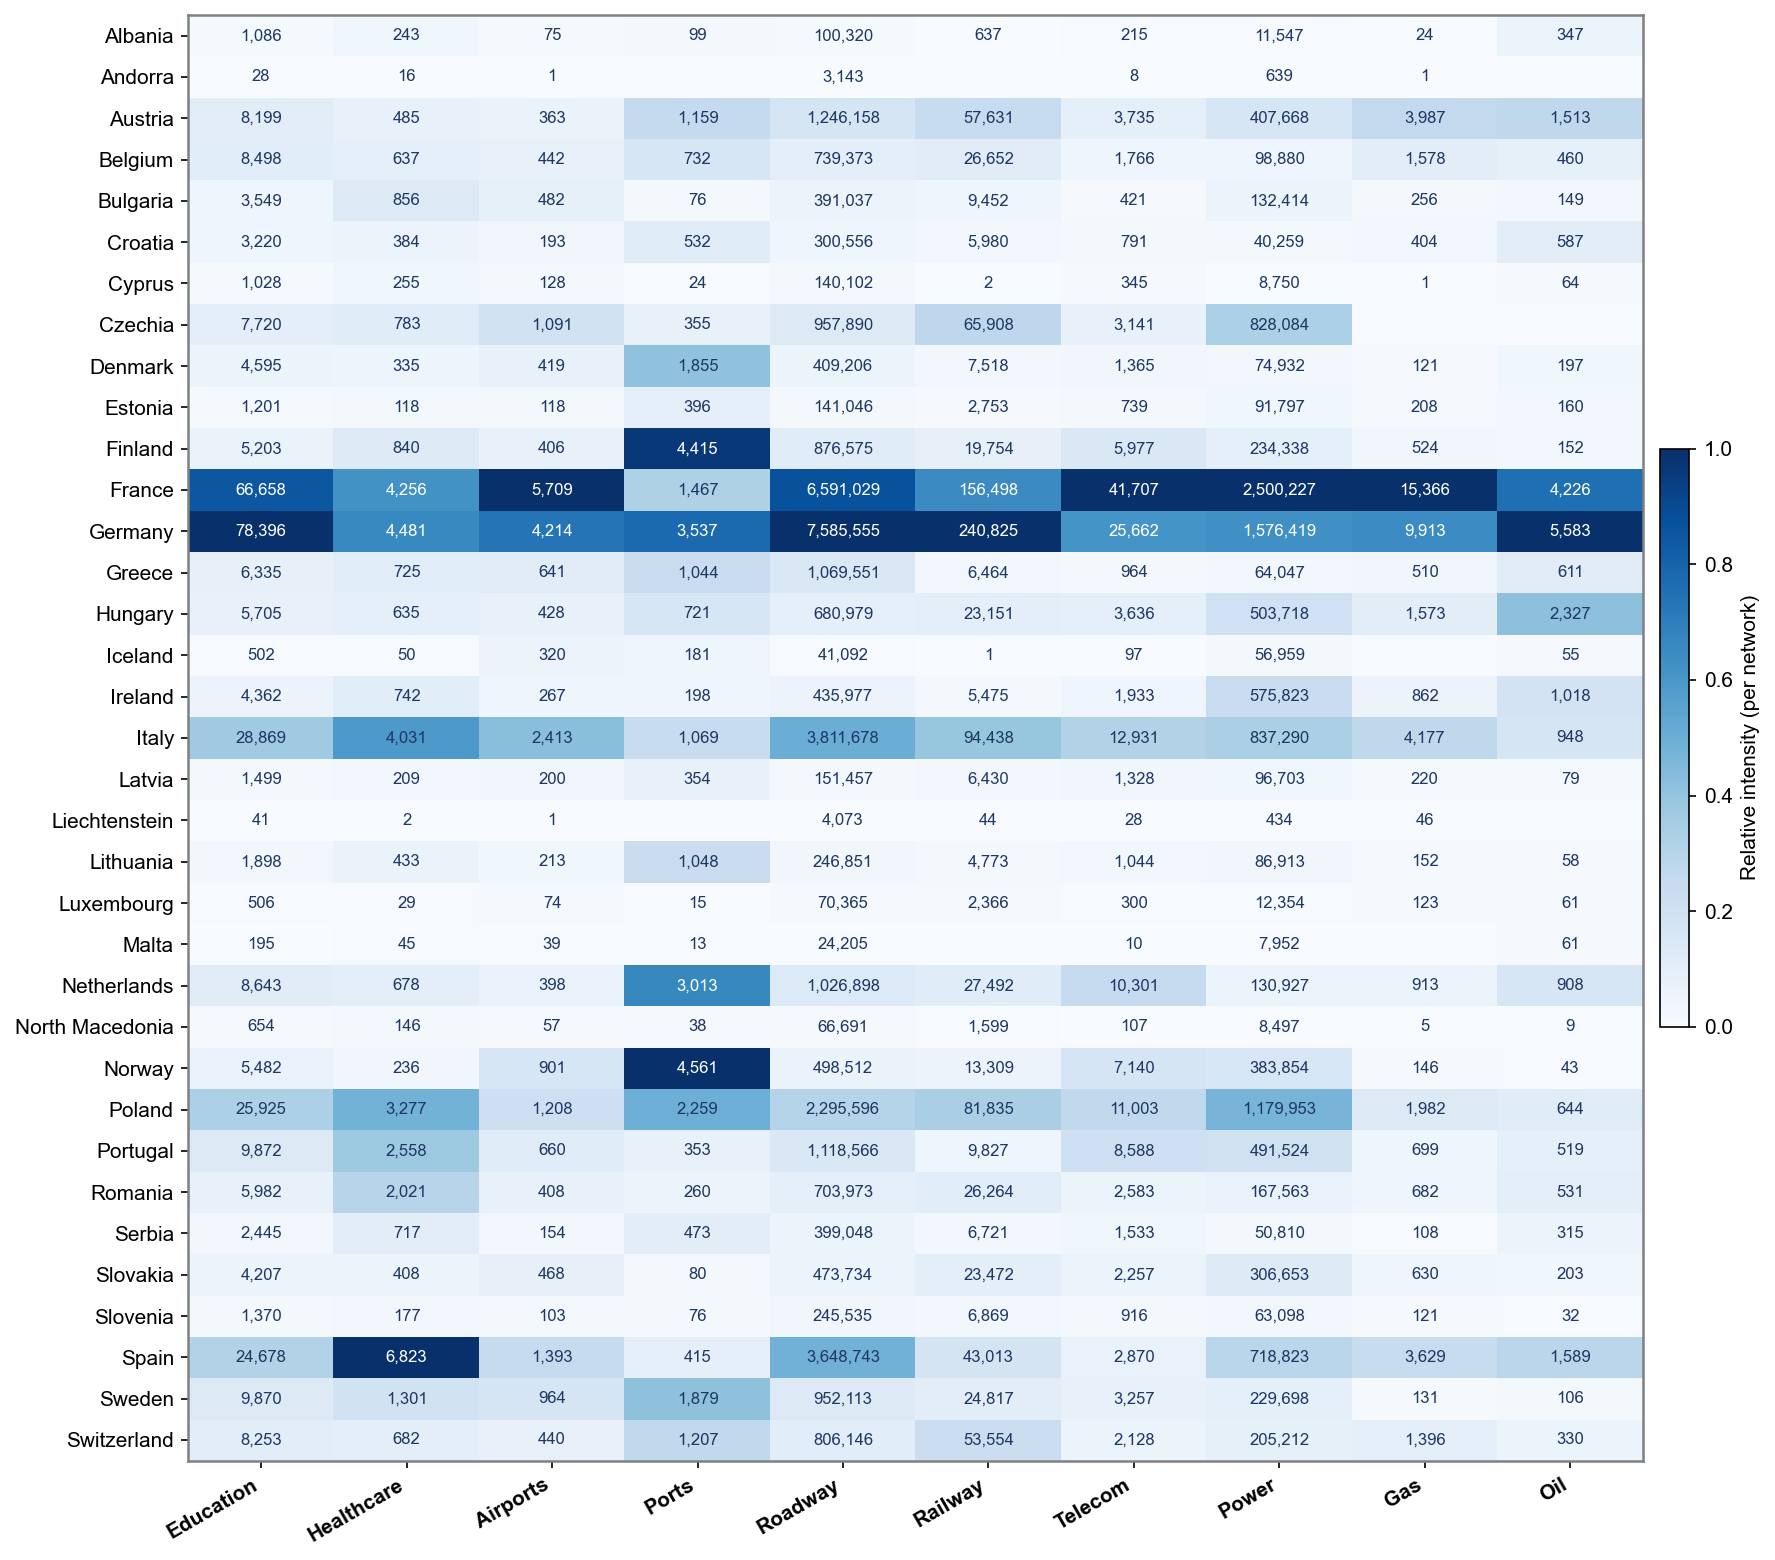

✔  Saved → C:\Users\Paraskevi Tsoumani\miraca_exposure_database\Final\heatmap_country_network.png


In [57]:
summary_heat = pd.DataFrame({
    net: df["TOTAL"] for net, df in all_tables.items()
}).fillna(0).astype(int)
summary_heat.index = summary_heat.index.str.replace(r"^[A-Z]{2} – ","",regex=True)
summary_heat = summary_heat.sort_index()

norm_heat = summary_heat.div(summary_heat.max()).fillna(0)

fig, ax = plt.subplots(figsize=(13, max(7, len(summary_heat)*0.30)))
im = ax.imshow(norm_heat.values, aspect="auto", cmap="Blues")

ax.set_xticks(range(len(summary_heat.columns)))
ax.set_xticklabels(summary_heat.columns, rotation=30, ha="right", fontsize=10, fontweight="bold")
ax.set_yticks(range(len(summary_heat.index)))
ax.set_yticklabels(summary_heat.index, fontsize=10)

for i in range(len(summary_heat.index)):
    for j in range(len(summary_heat.columns)):
        val = summary_heat.iloc[i,j]
        if val > 0:
            ax.text(j, i, f"{val:,}", ha="center", va="center",
                    fontsize=8,
                    color="white" if norm_heat.iloc[i,j] > 0.6 else "#1F3864")

#ax.set_title("Total features per Country × Network",
             #fontsize=13, fontweight="bold", pad=10, color="#1F3864")
plt.colorbar(im, ax=ax, label="Relative intensity (per network)", shrink=0.4, pad=0.01)


# Black border around the whole heatmap
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("grey")
    spine.set_linewidth(1.2)
plt.tight_layout()
out_hm = OUTPUT_DIR / "heatmap_country_network.png"
plt.savefig(out_hm, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"✔  Saved → {out_hm}")

## Section 7 – Top countries per network
Horizontal bar chart showing the **top 15 countries** by total feature count for each network.
Clean, minimal style — ready to paste directly into a paper.
Saved as `topN_{network}.png`.

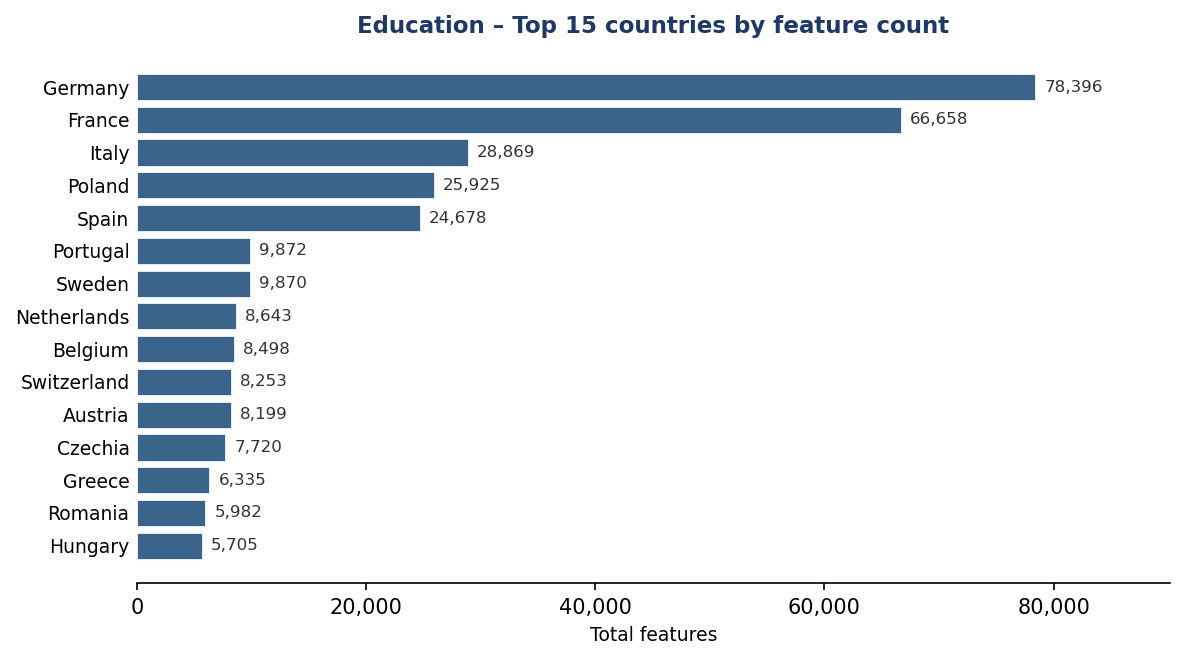

  Saved: topN_Education.png


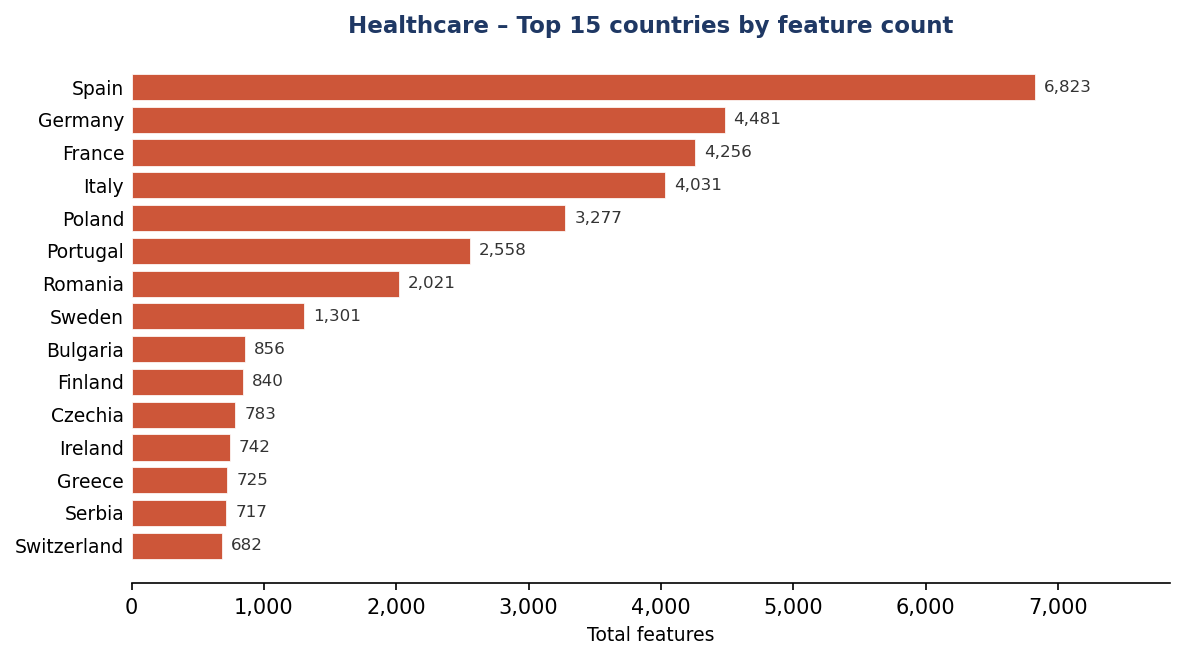

  Saved: topN_Healthcare.png


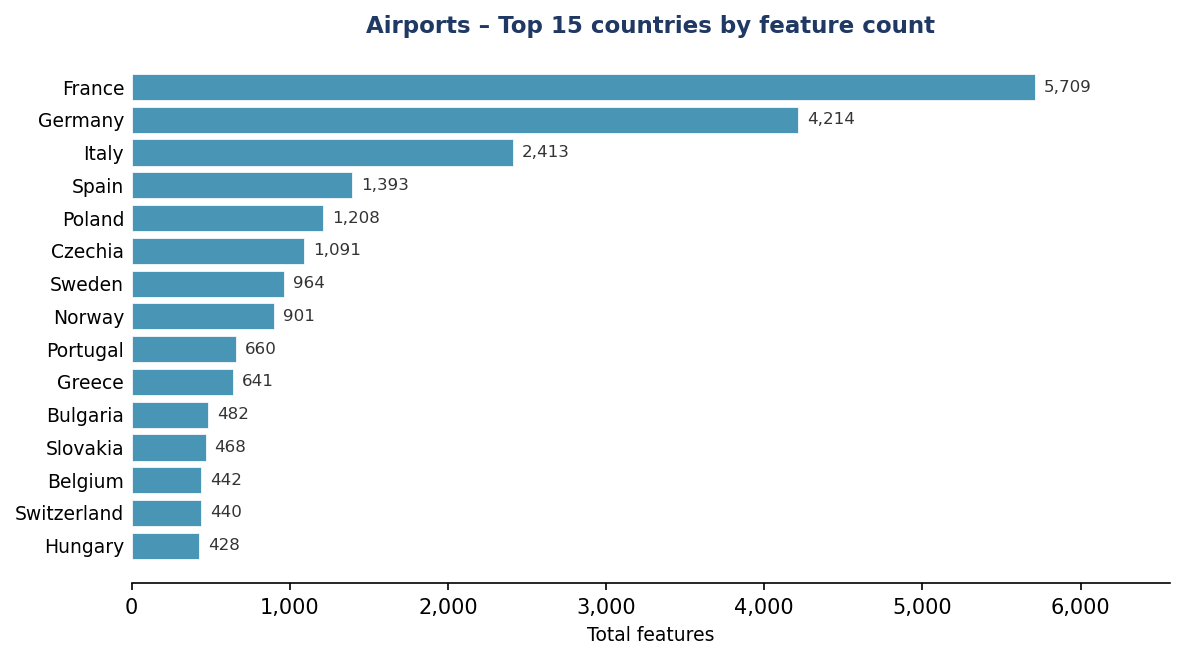

  Saved: topN_Airports.png


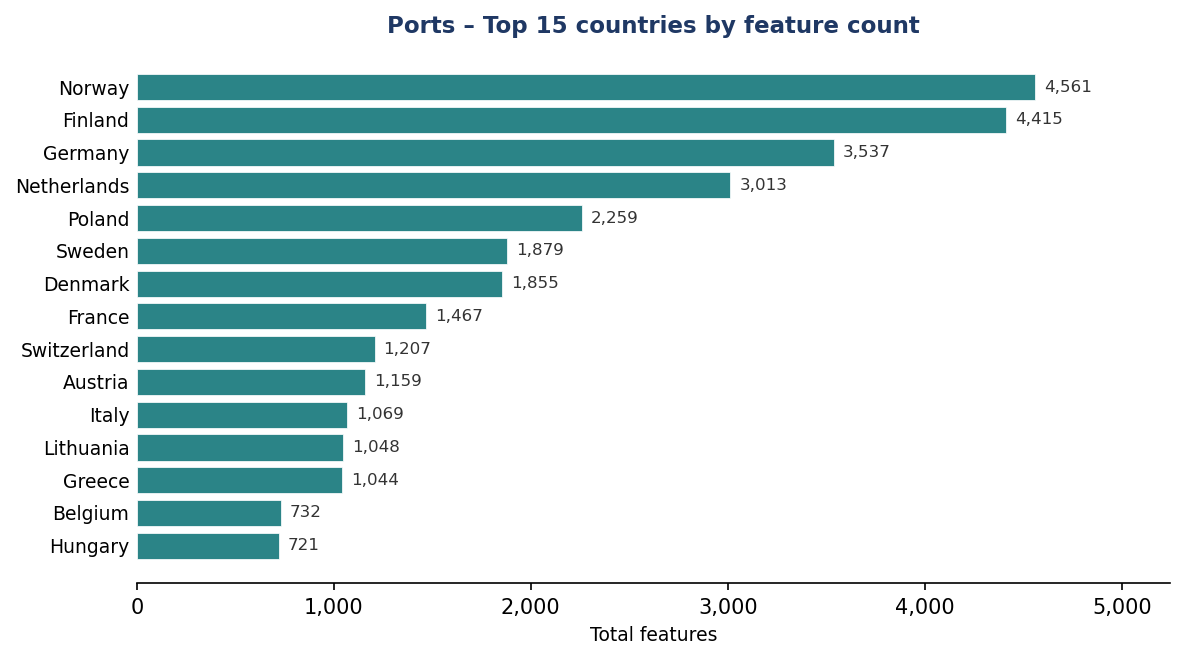

  Saved: topN_Ports.png


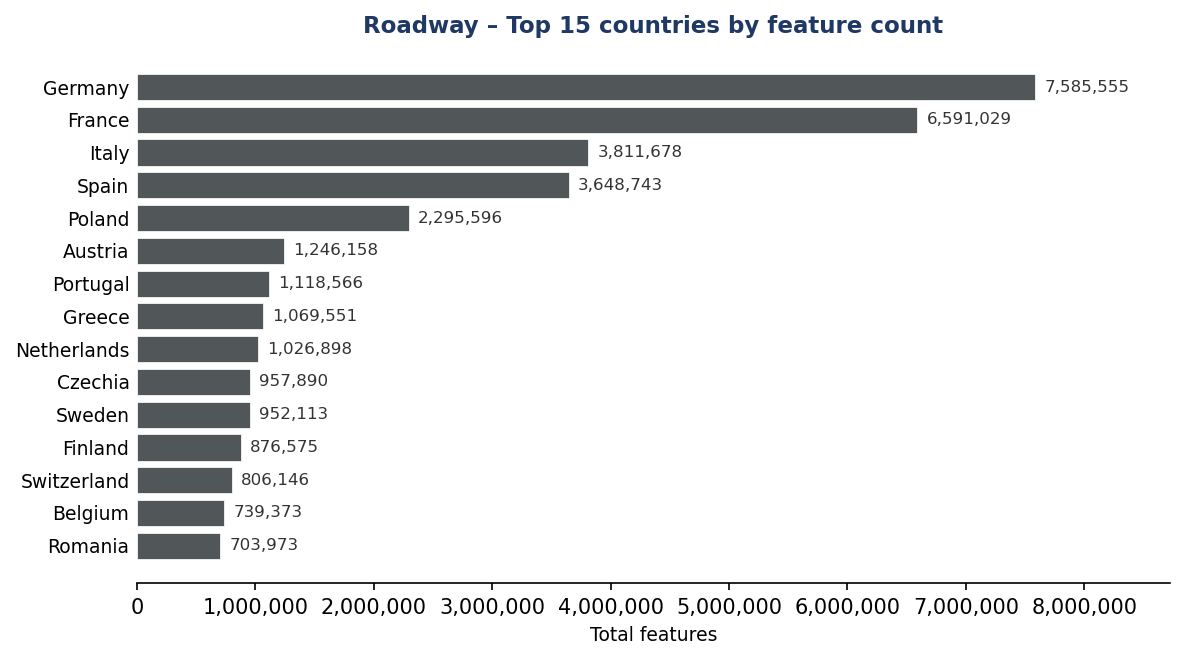

  Saved: topN_Roadway.png


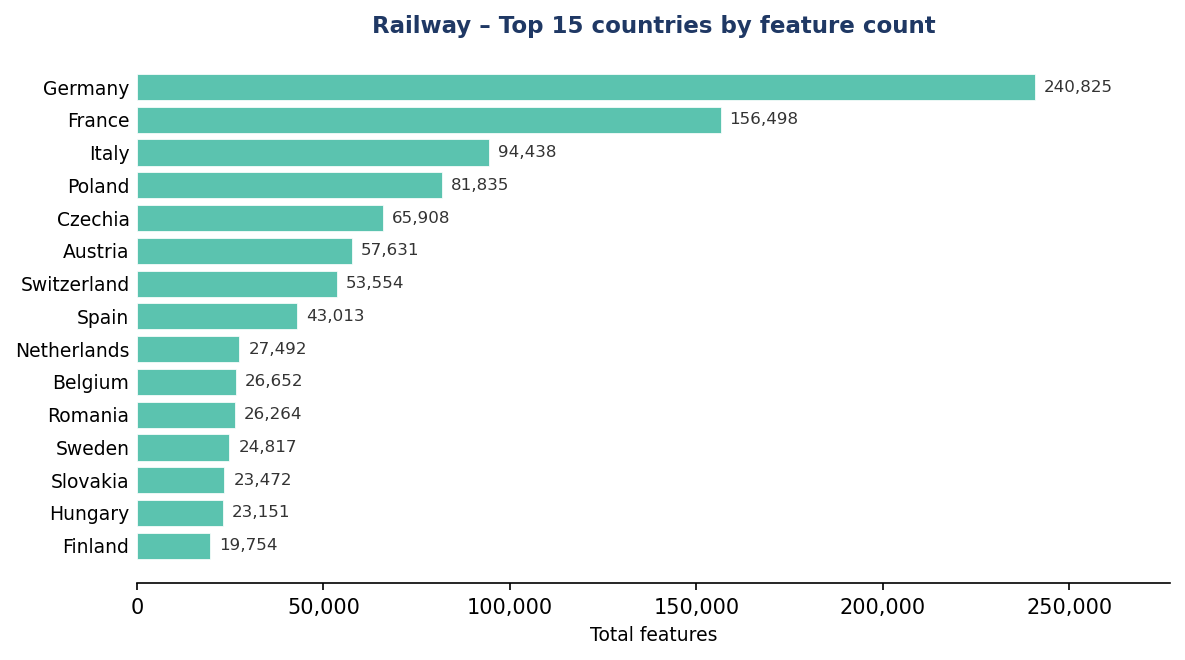

  Saved: topN_Railway.png


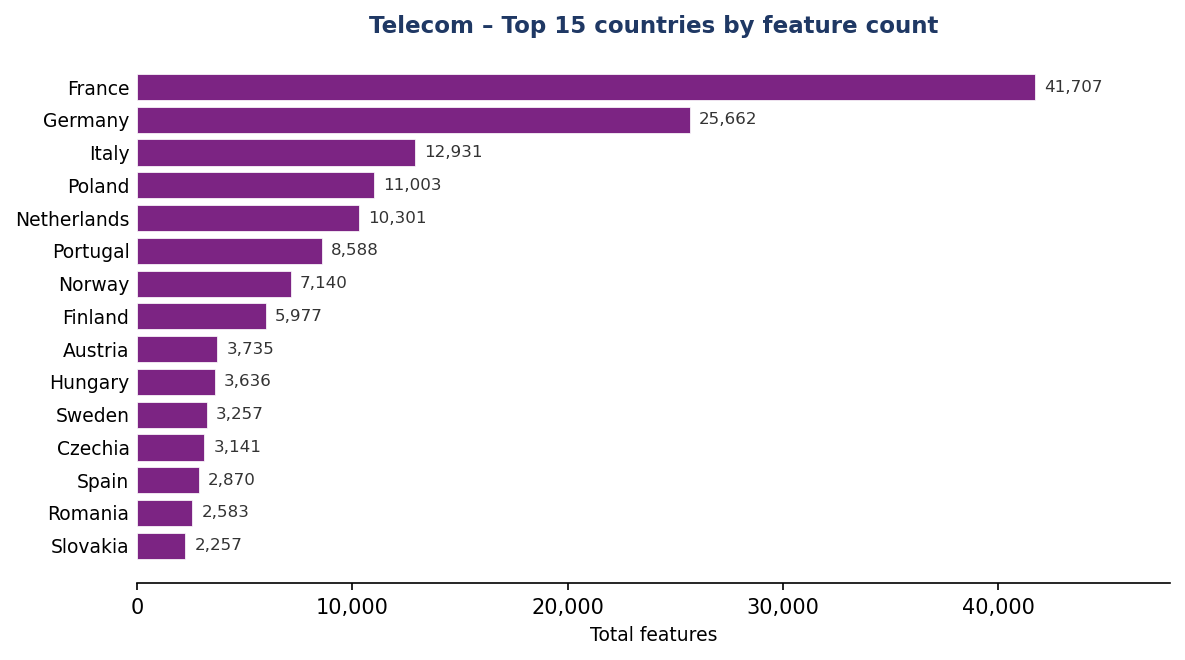

  Saved: topN_Telecom.png


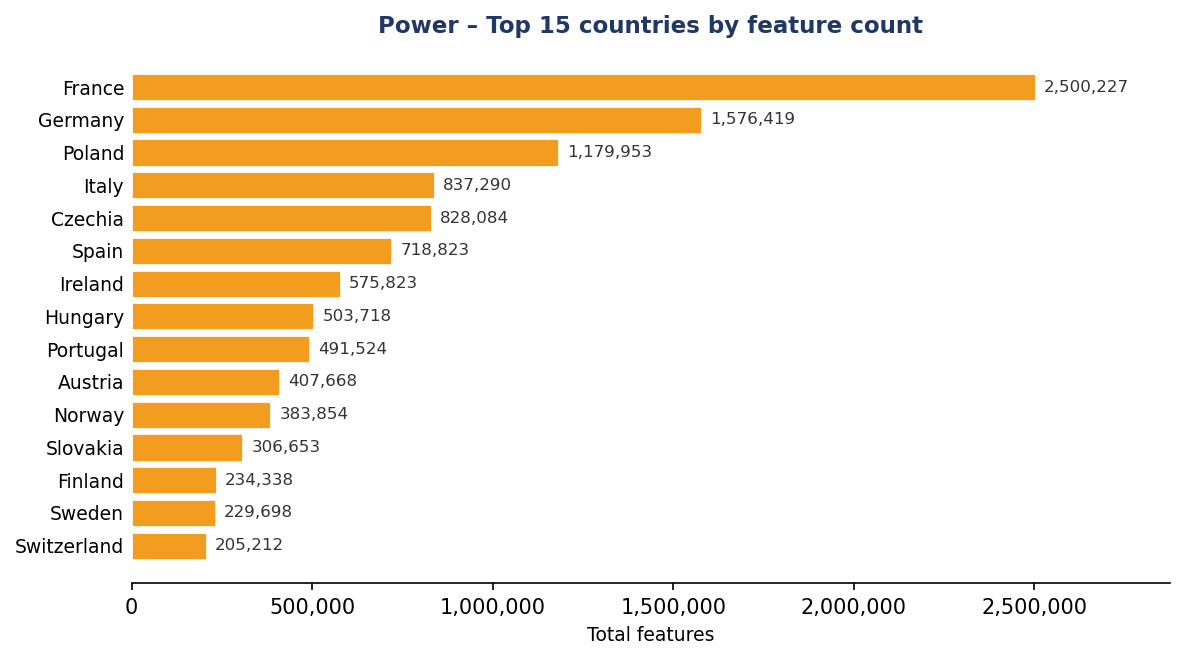

  Saved: topN_Power.png


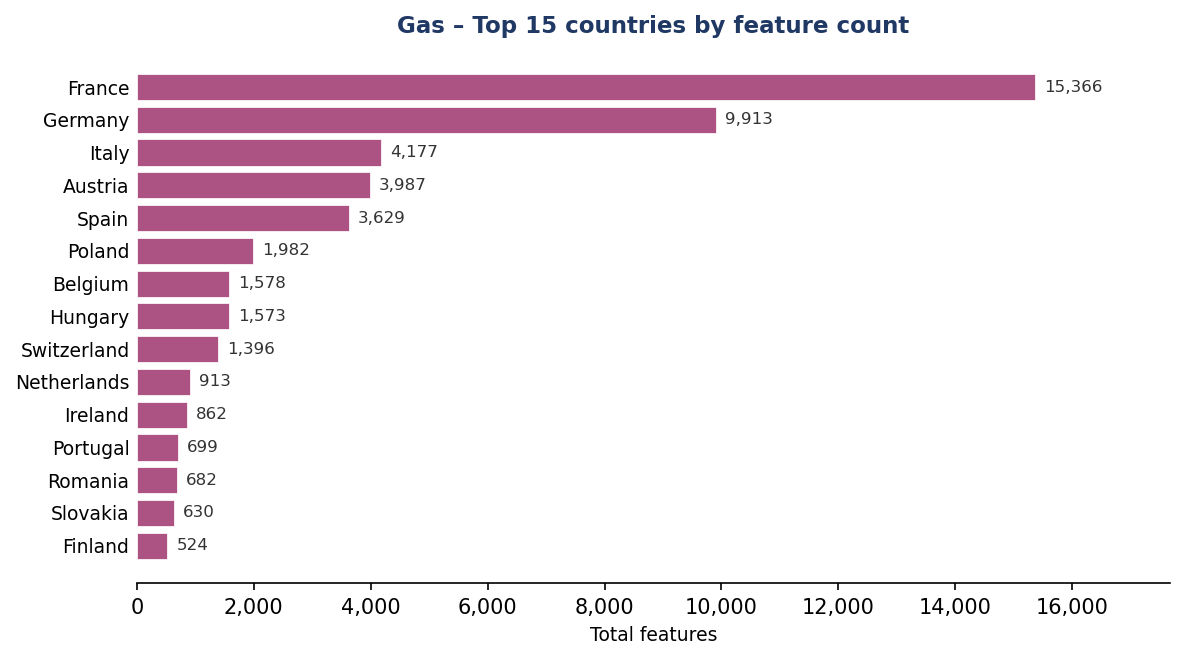

  Saved: topN_Gas.png


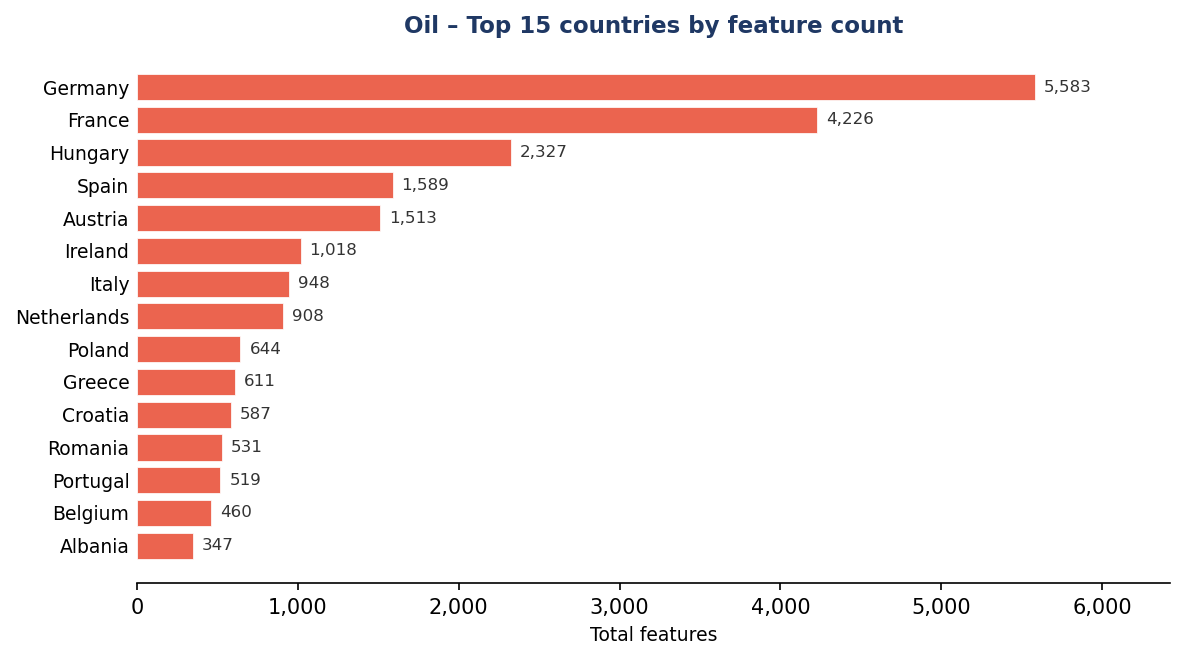

  Saved: topN_Oil.png


In [10]:
TOP_N = 15

for network, df in all_tables.items():
    top = df["TOTAL"].head(TOP_N).sort_values()
    labels = top.index.str.replace(r"^[A-Z]{2} – ","",regex=True)
    color  = NET_COLOR.get(network, "#2E86AB")

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.barh(labels, top.values, color=color, alpha=0.88,
                   edgecolor="white", linewidth=0.4)

    # Value labels at end of each bar
    for bar, val in zip(bars, top.values):
        ax.text(bar.get_width() + top.values.max()*0.01, bar.get_y() + bar.get_height()/2,
                f"{int(val):,}", va="center", ha="left", fontsize=8, color="#333333")

    ax.set_xlabel("Total features", fontsize=9)
    ax.set_title(f"{network} – Top {TOP_N} countries by feature count",
                 fontsize=11, fontweight="bold", pad=8, color="#1F3864")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
    ax.tick_params(axis="y", labelsize=9, length=0)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, top.values.max() * 1.15)
    plt.tight_layout()
    out = OUTPUT_DIR / f"topN_{network}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"  Saved: {out.name}")